# 데이터 살펴보기

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

## 구글 애널러틱스 전체 웹사이트 유입 전환 소스매체 구분(2021. 10 ~ 12)

In [152]:
df = pd.read_csv('./dataset/1. 구글 애널러틱스 전체 웹사이트 유입 전환 소스매체 구분(2021. 10. _ 12.) - 데이터세트1.csv')
df.head()

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,5051,4907,5921,78.16%,1.66,49.29,0.32%,19,0.0
1,naver / powerlink,4051,4006,4556,79.87%,1.52,31.98,0.72%,33,0.0
2,(direct) / (none),1057,1021,1750,70.23%,1.95,82.43,1.14%,20,0.0
3,naver / organic,749,623,1017,50.25%,2.77,123.73,1.18%,12,0.0
4,google / organic,598,493,868,58.29%,2.53,143.01,1.15%,10,0.0


In [153]:
df.shape

(114, 10)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   소스/매체                         113 non-null    object 
 1   사용자                           114 non-null    int64  
 2   신규 방문자                        114 non-null    int64  
 3   세션                            114 non-null    int64  
 4   이탈률                           114 non-null    object 
 5   세션당 페이지수                      114 non-null    float64
 6   평균 세션 시간                      114 non-null    float64
 7   문의하기 완료(유효성체크완료) (목표 5 전환율)   114 non-null    object 
 8   문의하기 완료(유효성체크완료) (목표 5 완료 수)  114 non-null    int64  
 9   문의하기 완료(유효성체크완료) (목표 5 가치)    114 non-null    float64
dtypes: float64(3), int64(4), object(3)
memory usage: 9.0+ KB


In [155]:
for col in df.columns:
    print(f"column : {col}")
    print(f"The number of unique : {df[col].nunique()}")
    print()

column : 소스/매체
The number of unique : 113

column : 사용자
The number of unique : 43

column : 신규 방문자
The number of unique : 36

column : 세션
The number of unique : 45

column : 이탈률
The number of unique : 51

column : 세션당 페이지수
The number of unique : 66

column : 평균 세션 시간
The number of unique : 86

column : 문의하기 완료(유효성체크완료) (목표 5 전환율)
The number of unique : 25

column : 문의하기 완료(유효성체크완료) (목표 5 완료 수)
The number of unique : 15

column : 문의하기 완료(유효성체크완료) (목표 5 가치)
The number of unique : 1



1. 이탈률, 문의하기 완료 숫자로 변환
2. 소스/매체별 그래프 그려보기
    - 사용자
    - 신규 방문자
    - 세션
    - 이탈률
    - 세션당 페이지수
    - 평균 세션 시간



In [156]:
df.head()

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,5051,4907,5921,78.16%,1.66,49.29,0.32%,19,0.0
1,naver / powerlink,4051,4006,4556,79.87%,1.52,31.98,0.72%,33,0.0
2,(direct) / (none),1057,1021,1750,70.23%,1.95,82.43,1.14%,20,0.0
3,naver / organic,749,623,1017,50.25%,2.77,123.73,1.18%,12,0.0
4,google / organic,598,493,868,58.29%,2.53,143.01,1.15%,10,0.0


In [157]:
df.loc[0, '이탈률'][:-1]

'78.16'

In [158]:
df.loc[0, '문의하기 완료(유효성체크완료) (목표 5 전환율)'][:-1]

'0.32'

In [159]:
# % 제거
for index in df.index:
    df.loc[index, '이탈률'] = df.loc[index, '이탈률'][:-1]
    df.loc[index, '문의하기 완료(유효성체크완료) (목표 5 전환율)'] = df.loc[index, '문의하기 완료(유효성체크완료) (목표 5 전환율)'][:-1]
print('% 제거 완료')
df.head()

% 제거 완료


,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0


In [160]:
# 숫자 타입으로 변환
df['이탈률'] = df['이탈률'].astype('float')
df['문의하기 완료(유효성체크완료) (목표 5 전환율)'] = df['문의하기 완료(유효성체크완료) (목표 5 전환율)'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   소스/매체                         113 non-null    object 
 1   사용자                           114 non-null    int64  
 2   신규 방문자                        114 non-null    int64  
 3   세션                            114 non-null    int64  
 4   이탈률                           114 non-null    float64
 5   세션당 페이지수                      114 non-null    float64
 6   평균 세션 시간                      114 non-null    float64
 7   문의하기 완료(유효성체크완료) (목표 5 전환율)   114 non-null    float64
 8   문의하기 완료(유효성체크완료) (목표 5 완료 수)  114 non-null    int64  
 9   문의하기 완료(유효성체크완료) (목표 5 가치)    114 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 9.0+ KB


### 그래프 그려보기

#### 사용자

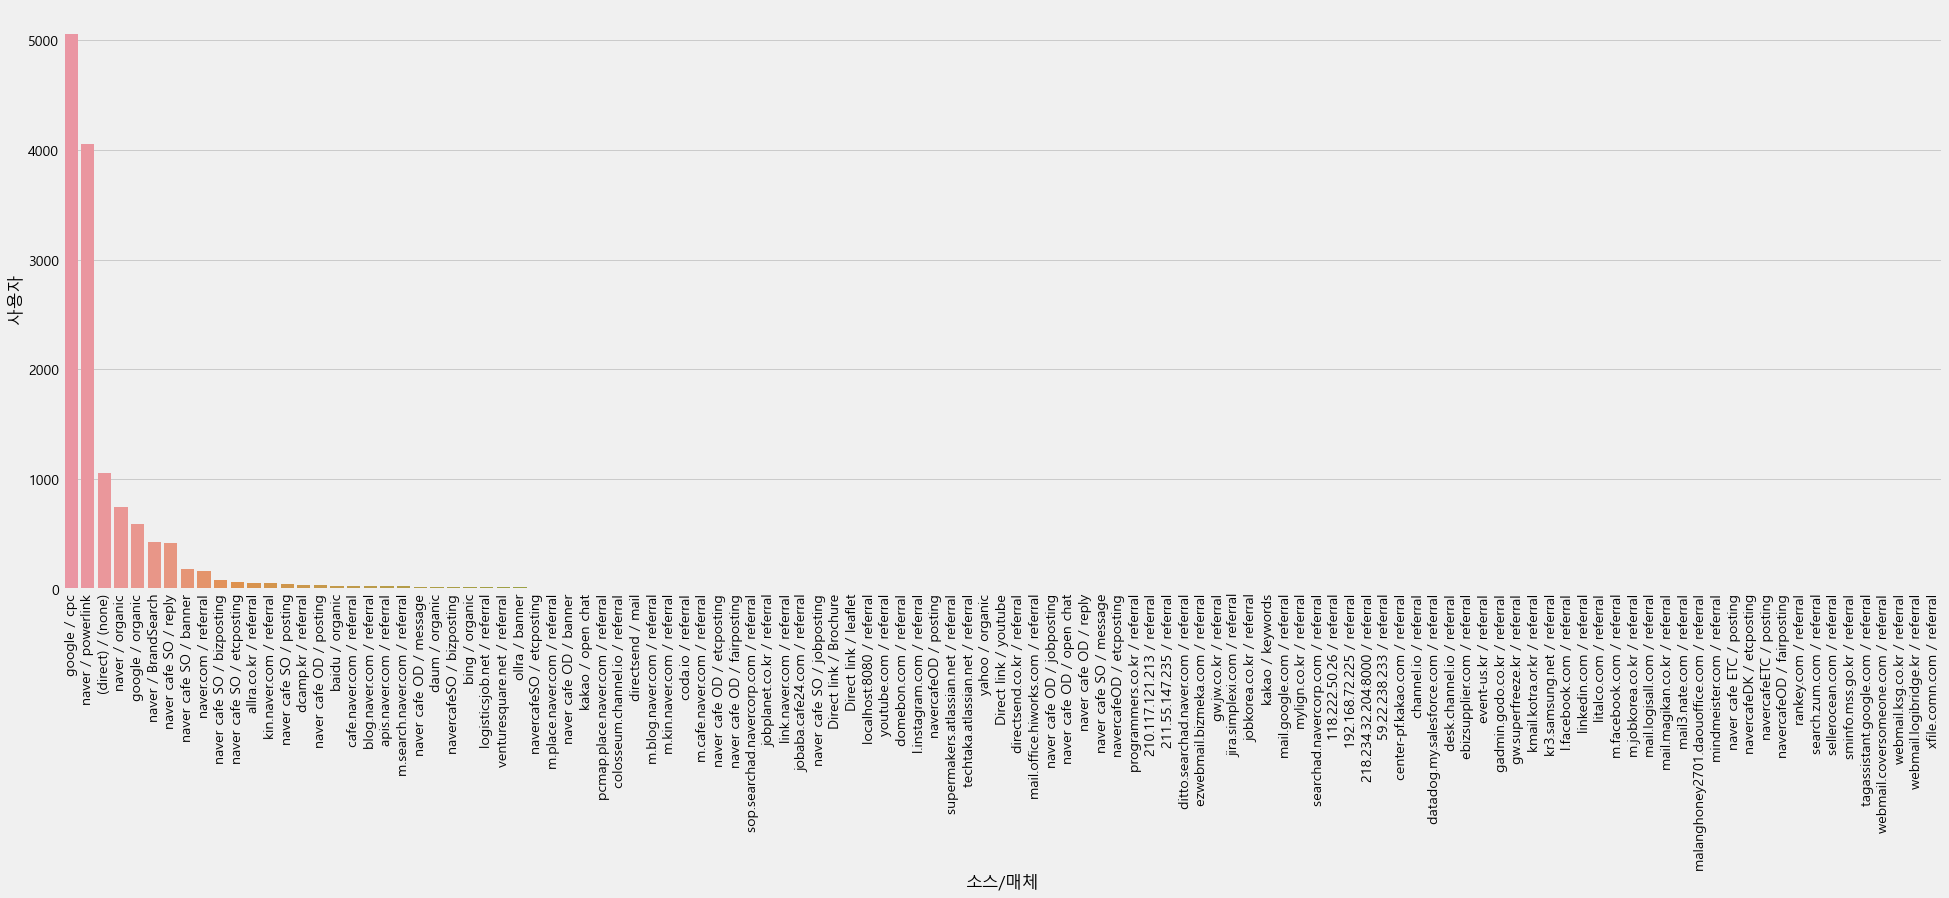

In [25]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['사용자'])
plt.xticks(rotation=90)
plt.show()

In [28]:
df[df['사용자']>1]

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
...,...,...,...,...,...,...,...,...,...,...
72,kakao / keywords,2,0,2,50.00,10.50,239.50,0.00,0,0.0
73,mail.google.com / referral,2,1,2,0.00,3.50,173.00,50.00,1,0.0
74,mylign.co.kr / referral,2,1,3,33.33,1.67,12.33,0.00,0,0.0
75,searchad.navercorp.com / referral,2,2,2,50.00,3.00,8.50,0.00,0,0.0


In [48]:
df.sort_values('사용자', ascending=False).head(30)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
113,NaN,13765,12925,17489,67.42,2.09,75.74,1.13,198,0.0
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
5,naver / BrandSearch,429,303,980,39.49,3.41,185.28,2.24,22,0.0
6,naver cafe SO / reply,422,387,545,21.47,3.93,136.13,6.42,35,0.0
7,naver cafe SO / banner,188,167,266,57.52,2.59,138.44,1.13,3,0.0
8,naver.com / referral,165,156,209,55.02,2.38,80.32,0.48,1,0.0


#### 신규 방문자

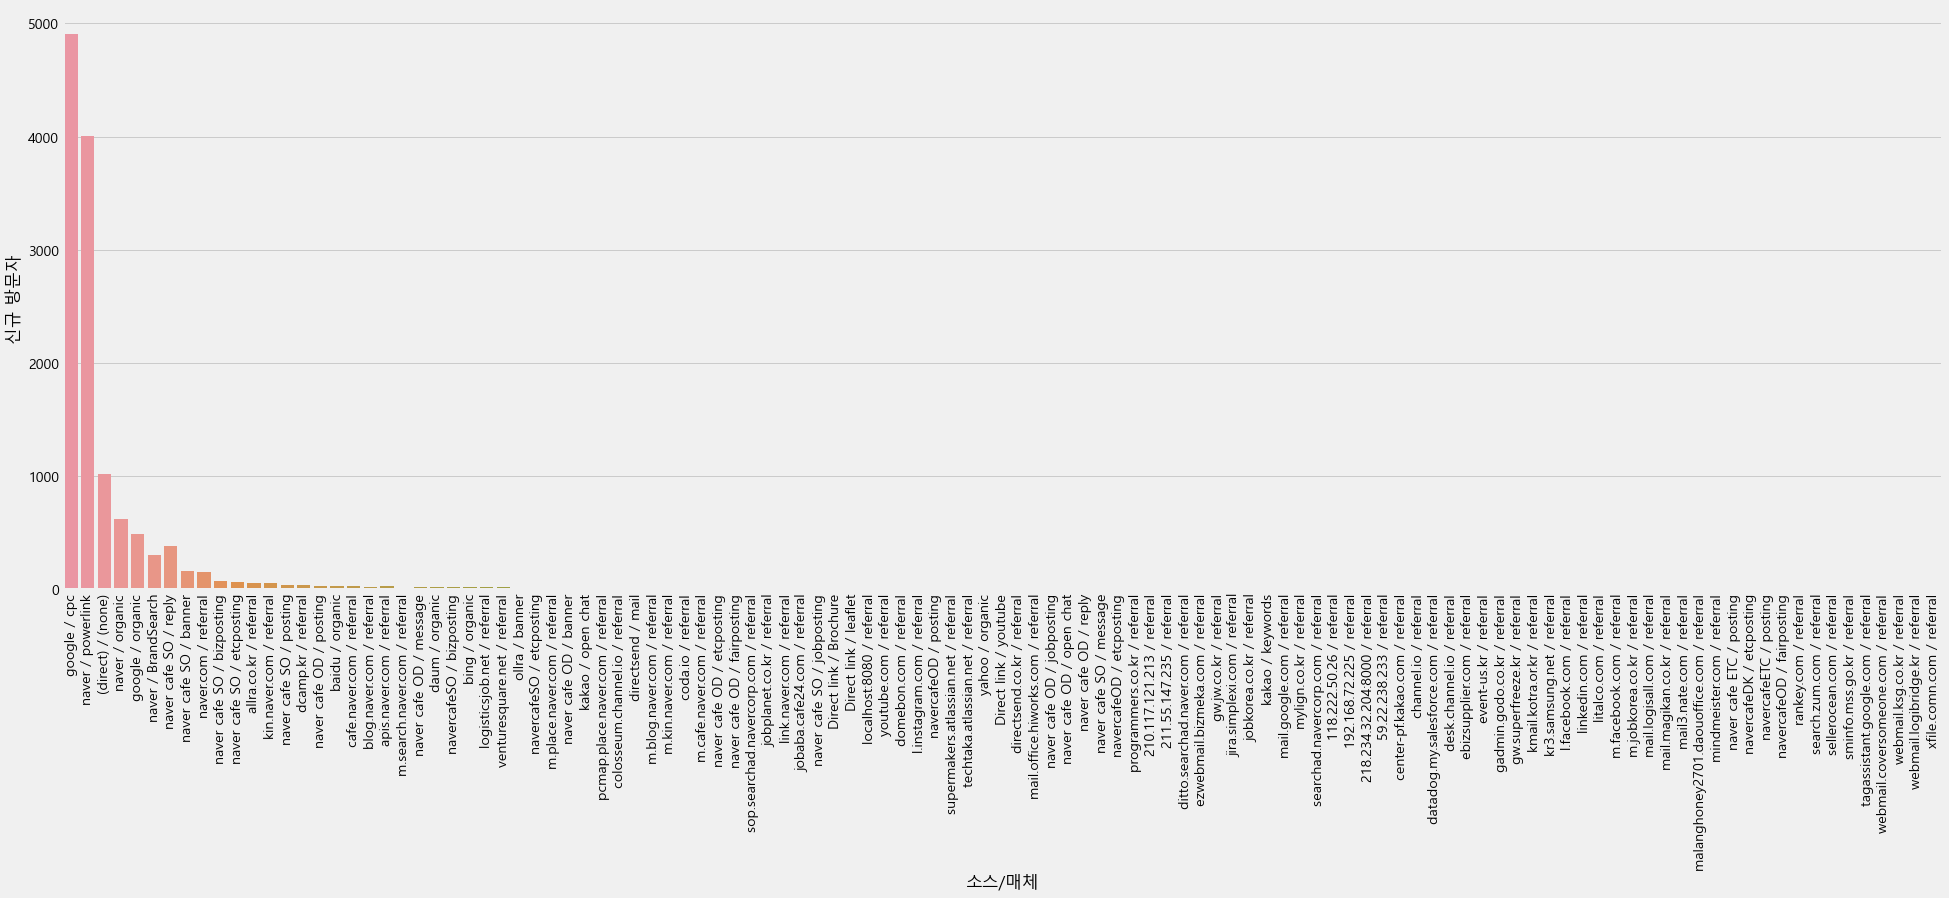

In [29]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['신규 방문자'])
plt.xticks(rotation=90)
plt.show()

In [49]:
df.sort_values('신규 방문자', ascending=False).head(30)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
113,NaN,13765,12925,17489,67.42,2.09,75.74,1.13,198,0.0
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
6,naver cafe SO / reply,422,387,545,21.47,3.93,136.13,6.42,35,0.0
5,naver / BrandSearch,429,303,980,39.49,3.41,185.28,2.24,22,0.0
7,naver cafe SO / banner,188,167,266,57.52,2.59,138.44,1.13,3,0.0
8,naver.com / referral,165,156,209,55.02,2.38,80.32,0.48,1,0.0


#### 세션

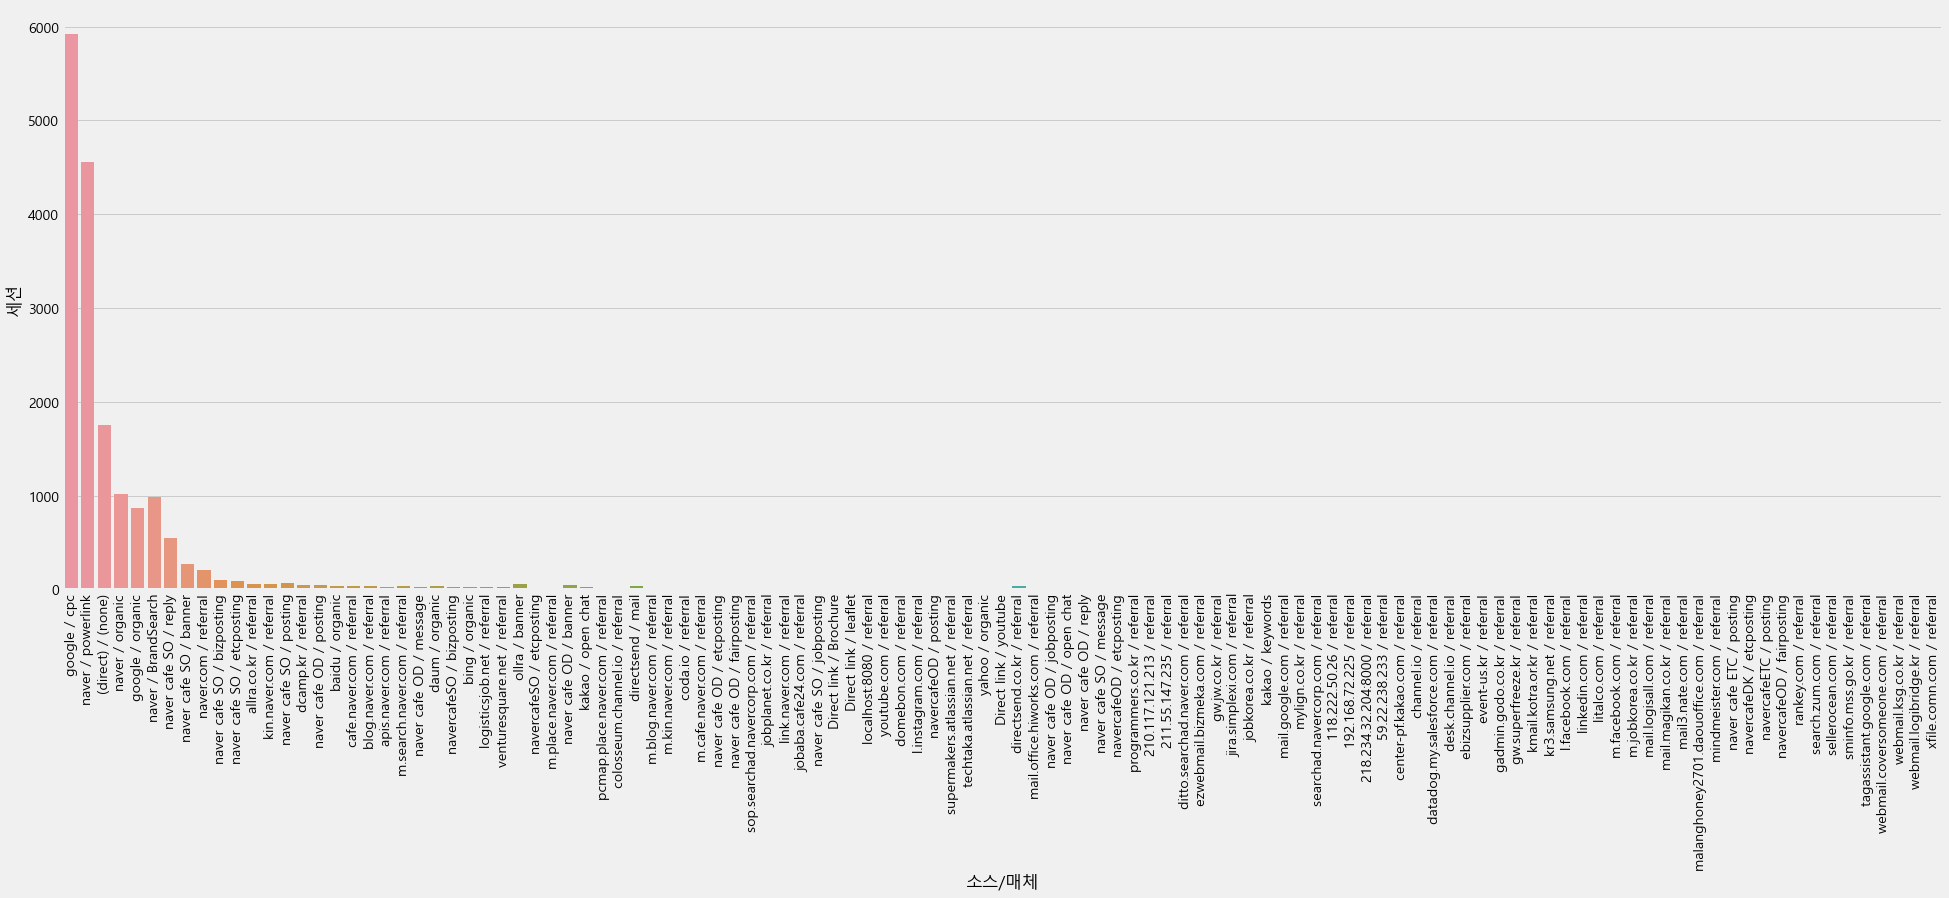

In [30]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['세션'])
plt.xticks(rotation=90)
plt.show()

In [50]:
df.sort_values('세션', ascending=False).head(30)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
113,NaN,13765,12925,17489,67.42,2.09,75.74,1.13,198,0.0
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
5,naver / BrandSearch,429,303,980,39.49,3.41,185.28,2.24,22,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
6,naver cafe SO / reply,422,387,545,21.47,3.93,136.13,6.42,35,0.0
7,naver cafe SO / banner,188,167,266,57.52,2.59,138.44,1.13,3,0.0
8,naver.com / referral,165,156,209,55.02,2.38,80.32,0.48,1,0.0


#### 이탈률

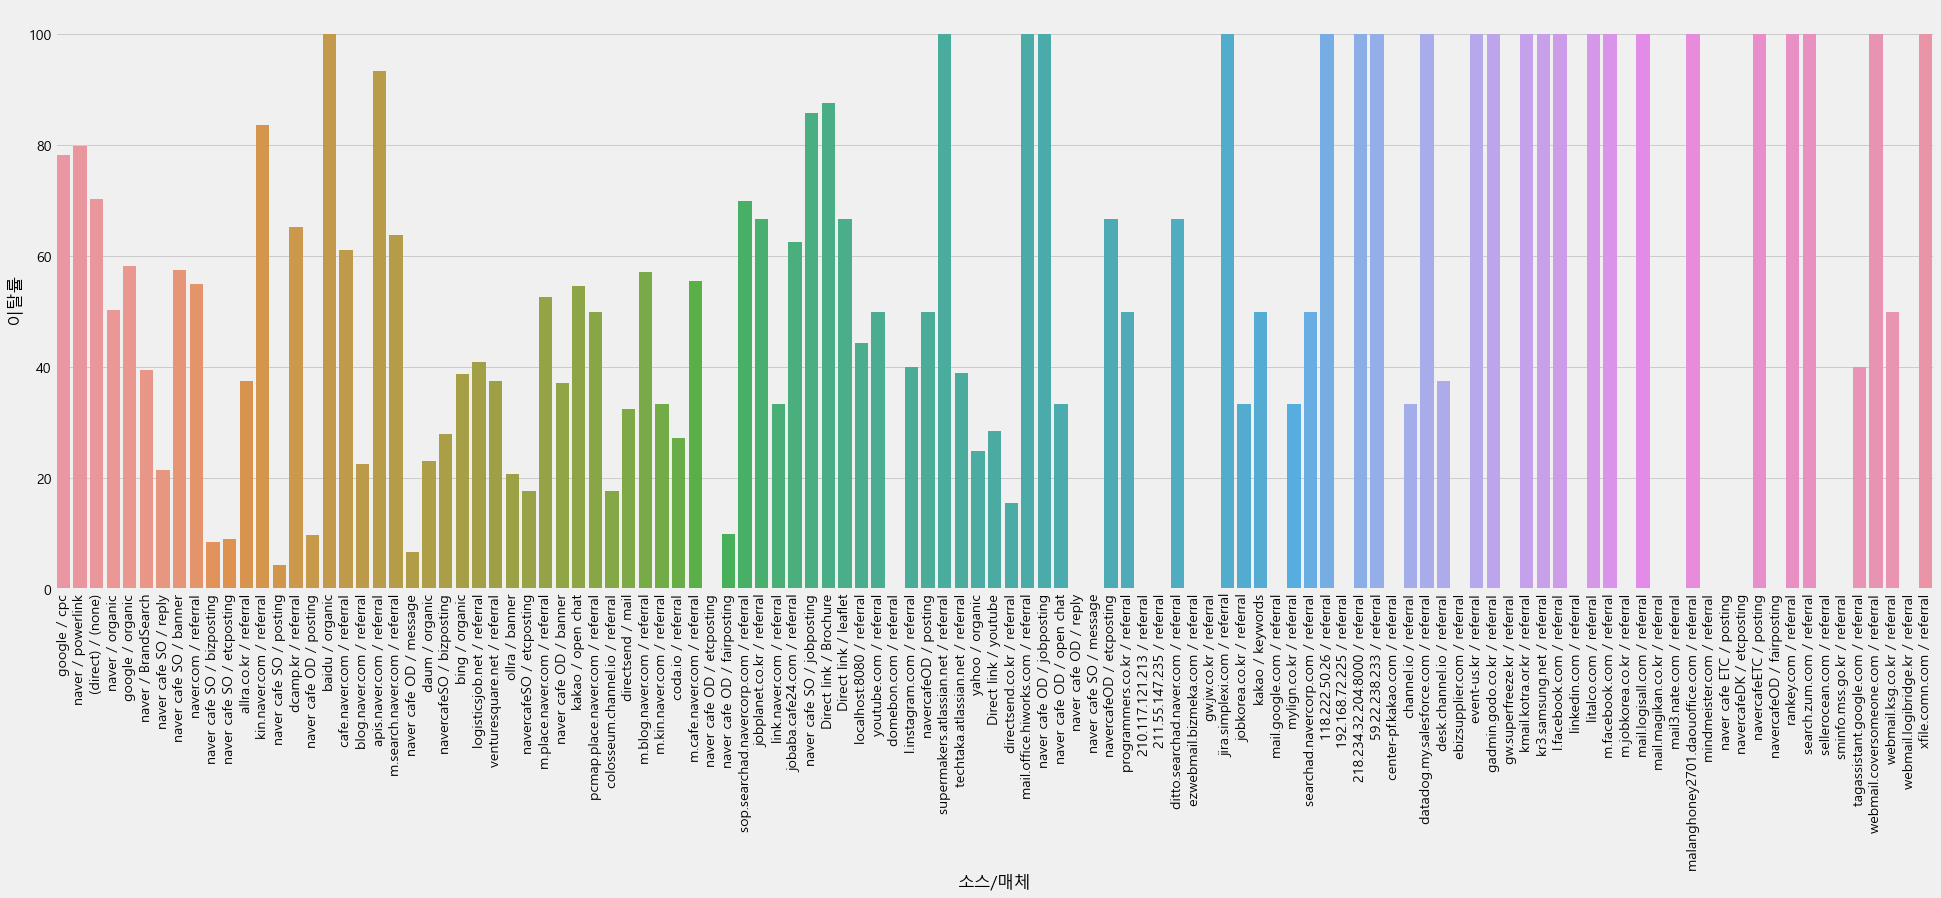

In [31]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['이탈률'])
plt.xticks(rotation=90)
plt.show()

#### 세션당 페이지수

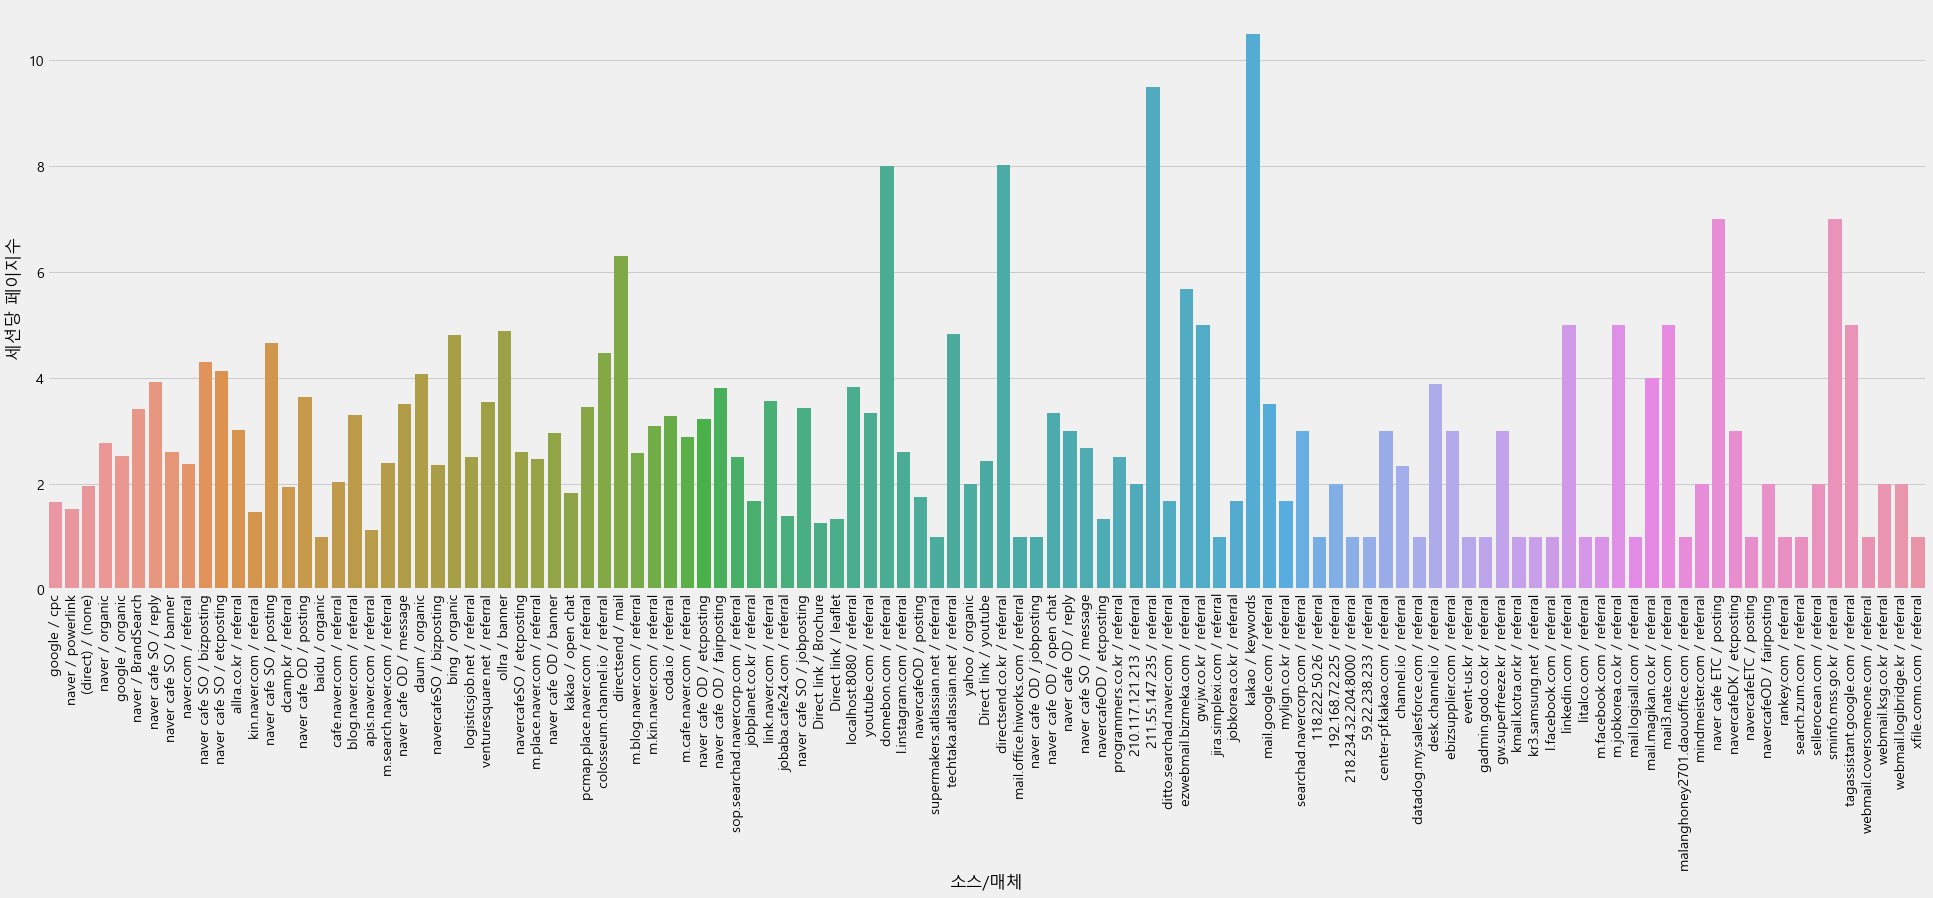

In [32]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['세션당 페이지수'])
plt.xticks(rotation=90)
plt.show()

In [34]:
df.sort_values('세션당 페이지수', ascending=False)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
72,kakao / keywords,2,0,2,50.00,10.50,239.50,0.0,0,0.0
66,211.55.147.235 / referral,2,2,2,0.00,9.50,1053.00,50.0,1,0.0
57,directsend.co.kr / referral,3,1,32,15.63,8.03,481.69,0.0,0,0.0
50,domebon.com / referral,4,4,6,0.00,8.00,202.50,0.0,0,0.0
100,naver cafe ETC / posting,1,1,1,0.00,7.00,123.00,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
82,datadog.my.salesforce.com / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0
89,kr3.samsung.net / referral,1,1,2,100.00,1.00,0.00,0.0,0,0.0
88,kmail.kotra.or.kr / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0
86,gadmin.godo.co.kr / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0


#### 평균 세션 시간

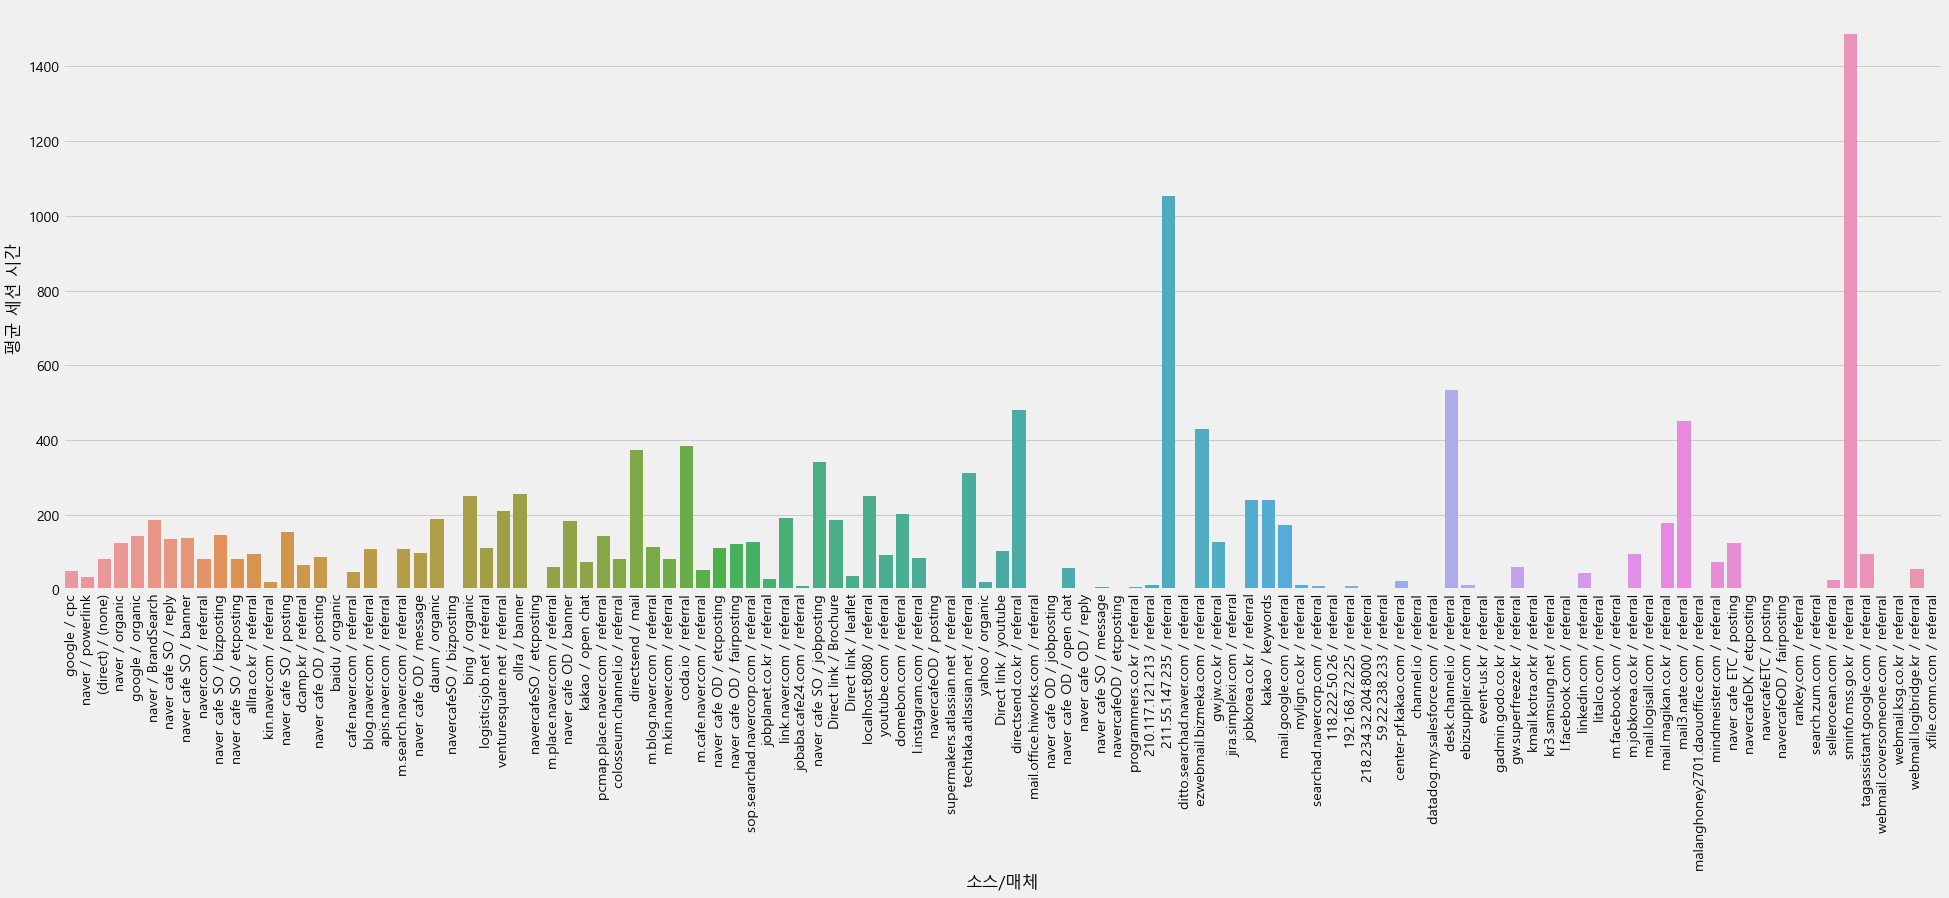

In [35]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['평균 세션 시간'])
plt.xticks(rotation=90)
plt.show()

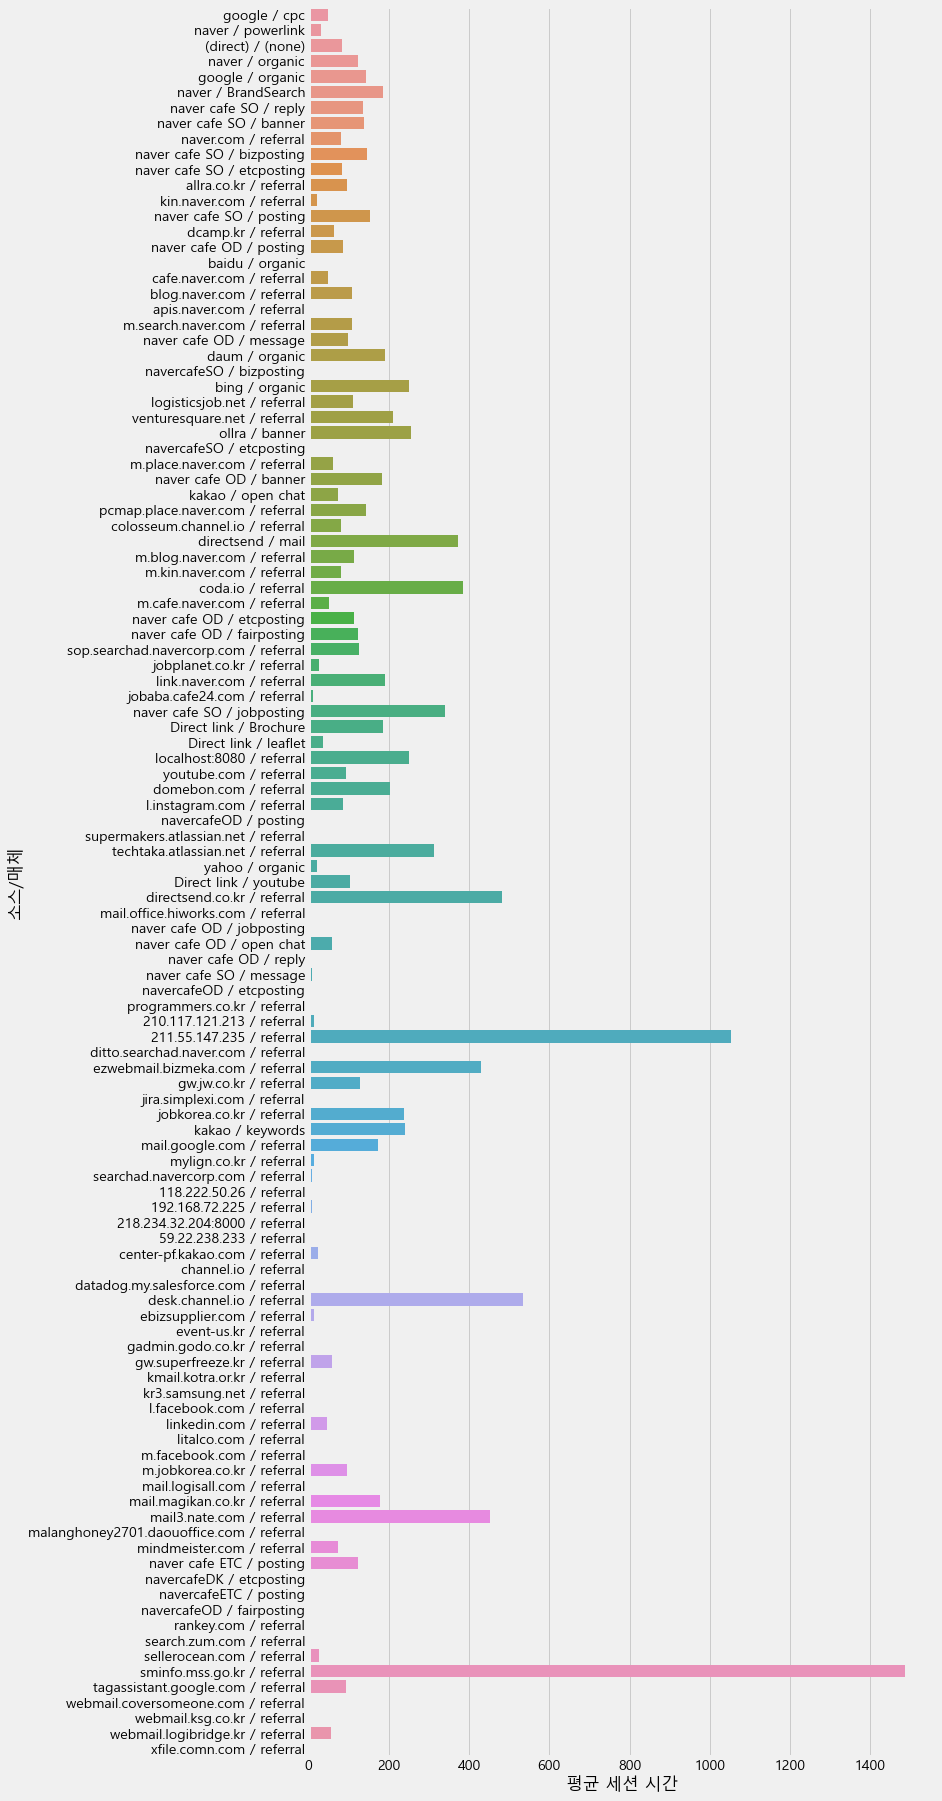

In [39]:
plt.figure(figsize=(10, 30))
sns.barplot(x=df['평균 세션 시간'], y=df['소스/매체'])
# plt.xticks(rotation=90)
plt.show()

In [40]:
df.sort_values('평균 세션 시간', ascending=False)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
107,sminfo.mss.go.kr / referral,1,0,1,0.00,7.00,1487.00,0.0,0,0.0
66,211.55.147.235 / referral,2,2,2,0.00,9.50,1053.00,50.0,1,0.0
83,desk.channel.io / referral,1,0,8,37.50,3.88,534.75,0.0,0,0.0
57,directsend.co.kr / referral,3,1,32,15.63,8.03,481.69,0.0,0,0.0
97,mail3.nate.com / referral,1,1,1,0.00,5.00,452.00,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
82,datadog.my.salesforce.com / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0
79,59.22.238.233 / referral,1,0,1,100.00,1.00,0.00,0.0,0,0.0
78,218.234.32.204:8000 / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0
76,118.222.50.26 / referral,1,1,1,100.00,1.00,0.00,0.0,0,0.0


#### 문의하기 완료(유효성체크완료) (목표 5 전환율)

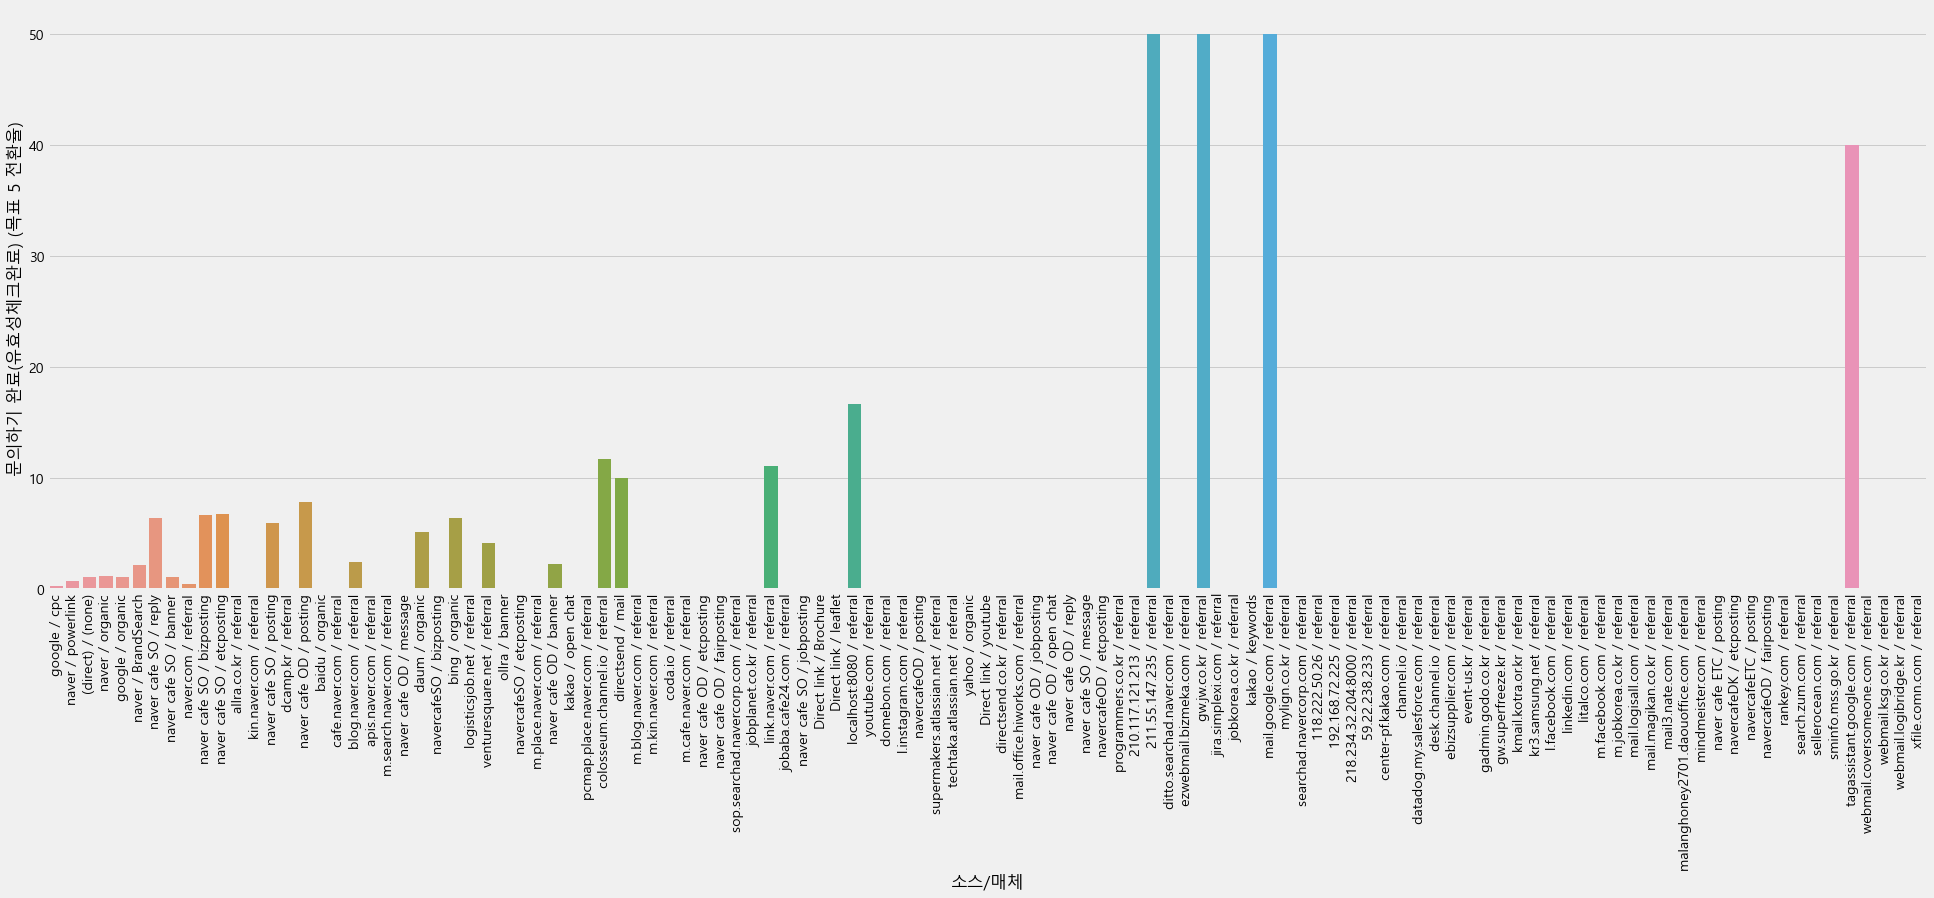

In [41]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['문의하기 완료(유효성체크완료) (목표 5 전환율)'])
plt.xticks(rotation=90)
plt.show()

#### 문의하기 완료(유효성체크완료) (목표 5 완료 수)

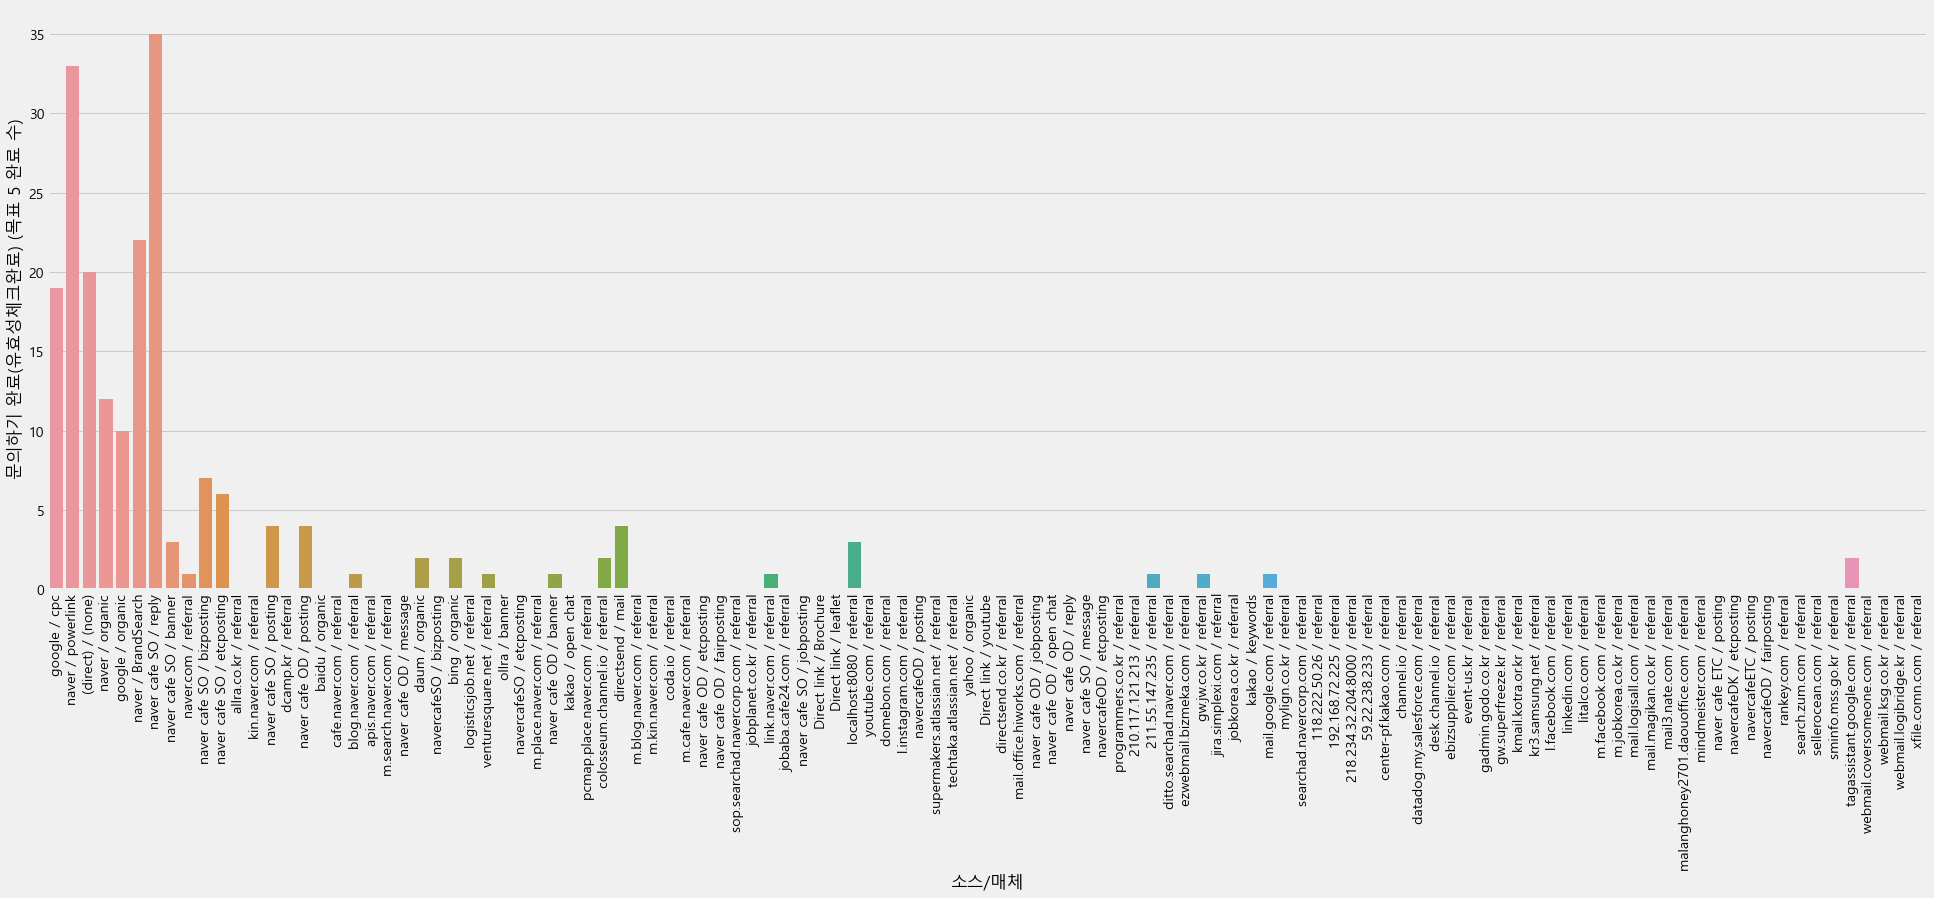

In [42]:
plt.figure(figsize=(30, 10))
sns.barplot(x=df['소스/매체'], y=df['문의하기 완료(유효성체크완료) (목표 5 완료 수)'])
plt.xticks(rotation=90)
plt.show()

In [44]:
df.sort_values('문의하기 완료(유효성체크완료) (목표 5 완료 수)', ascending=False).head(30)

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
113,NaN,13765,12925,17489,67.42,2.09,75.74,1.13,198,0.0
6,naver cafe SO / reply,422,387,545,21.47,3.93,136.13,6.42,35,0.0
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
5,naver / BrandSearch,429,303,980,39.49,3.41,185.28,2.24,22,0.0
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
9,naver cafe SO / bizposting,87,71,105,8.57,4.29,145.51,6.67,7,0.0
10,naver cafe SO / etcposting,71,69,88,9.09,4.13,82.30,6.82,6,0.0


In [45]:
df.iloc[113]

소스/매체                             NaN
사용자                             13765
신규 방문자                          12925
세션                              17489
이탈률                             67.42
세션당 페이지수                         2.09
평균 세션 시간                        75.74
문의하기 완료(유효성체크완료) (목표 5 전환율)      1.13
문의하기 완료(유효성체크완료) (목표 5 완료 수)      198
문의하기 완료(유효성체크완료) (목표 5 가치)        0.0
Name: 113, dtype: object

+ 마지막 줄은 전체적인 데이터 합 또는 평균

### 소스/매체 나눠보기

In [161]:
df['소스'] = np.nan
df['매체'] = np.nan

try:
    for index in df.index:
        df.loc[index, '소스'], df.loc[index, '매체'] = df.loc[index, '소스/매체'].split(' / ')
        
except:
    print('오류 발생!', index)

오류 발생! 113


In [162]:
df.head()

,소스/매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치),소스,매체
0,google / cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0,google,cpc
1,naver / powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0,naver,powerlink
2,(direct) / (none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0,(direct),(none)
3,naver / organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0,naver,organic
4,google / organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0,google,organic


In [163]:
df.columns

Index(['소스/매체', '사용자', '신규 방문자', '세션', '이탈률', '세션당 페이지수', '평균 세션 시간',
       '문의하기 완료(유효성체크완료) (목표 5 전환율)', '문의하기 완료(유효성체크완료) (목표 5 완료 수)',
       '문의하기 완료(유효성체크완료) (목표 5 가치)', '소스', '매체'],
      dtype='object')

In [164]:
df = df[['소스/매체', '소스', '매체', '사용자', '신규 방문자', '세션', '이탈률', '세션당 페이지수', '평균 세션 시간', '문의하기 완료(유효성체크완료) (목표 5 전환율)', '문의하기 완료(유효성체크완료) (목표 5 완료 수)', '문의하기 완료(유효성체크완료) (목표 5 가치)']]
df.head()

,소스/매체,소스,매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,google,cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,naver,powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),(direct),(none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,naver,organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,google,organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0


In [165]:
df['소스'].value_counts().head(30)

naver cafe OD              8
naver cafe SO              7
navercafeOD                3
naver                      3
Direct link                3
kakao                      2
navercafeSO                2
google                     2
navercafeDK                1
localhost:8080             1
daum                       1
pcmap.place.naver.com      1
directsend                 1
sminfo.mss.go.kr           1
mail.office.hiworks.com    1
jobkorea.co.kr             1
xfile.comn.com             1
gadmin.godo.co.kr          1
baidu                      1
118.222.50.26              1
techtaka.atlassian.net     1
rankey.com                 1
mindmeister.com            1
jira.simplexi.com          1
center-pf.kakao.com        1
navercafeETC               1
searchad.navercorp.com     1
webmail.logibridge.kr      1
naver.com                  1
blog.naver.com             1
Name: 소스, dtype: int64

In [180]:
for index in df.index:
    if df.loc[index, '소스'] == 'navercafeOD':
        df.loc[index, '소스'] = 'naver cafe OD'
    elif df.loc[index, '소스'] == 'navercafeSO':
        df.loc[index, '소스'] = 'naver cafe SO'
    elif df.loc[index, '소스'] == 'navercafeDK':
        df.loc[index, '소스'] = 'naver cafe DK'
    elif df.loc[index, '소스'] == 'navercafeETC':
        df.loc[index, '소스'] = 'naver cafe ETC'
    elif df.loc[index, '소스'] == 'naver.com':
        df.loc[index, '소스'] = 'naver'

In [183]:
df

,소스/매체,소스,매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,google,cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,naver,powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),(direct),(none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,naver,organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,google,organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
109,webmail.coversomeone.com / referral,webmail.coversomeone.com,referral,1,1,1,100.00,1.00,0.00,0.00,0,0.0
110,webmail.ksg.co.kr / referral,webmail.ksg.co.kr,referral,1,1,2,50.00,2.00,1.00,0.00,0,0.0
111,webmail.logibridge.kr / referral,webmail.logibridge.kr,referral,1,0,1,0.00,2.00,55.00,0.00,0,0.0
112,xfile.comn.com / referral,xfile.comn.com,referral,1,1,1,100.00,1.00,0.00,0.00,0,0.0


In [184]:
df.groupby('소스').sum().sort_values('세션', ascending=False)

,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
소스,,,,,,,,,
google,5649,5400,6789,136.45,4.19,192.30,1.47,29,0.0
naver,5394,5088,6762,224.63,10.08,421.31,4.62,68,0.0
(direct),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
naver cafe SO,871,779,1123,232.49,30.65,1004.01,27.01,55,0.0
naver cafe OD,117,99,160,313.68,29.51,661.03,10.17,5,0.0
...,...,...,...,...,...,...,...,...,...
mail.magikan.co.kr,1,1,1,0.00,4.00,179.00,0.00,0,0.0
mail3.nate.com,1,1,1,0.00,5.00,452.00,0.00,0,0.0
mindmeister.com,1,1,1,0.00,2.00,74.00,0.00,0,0.0


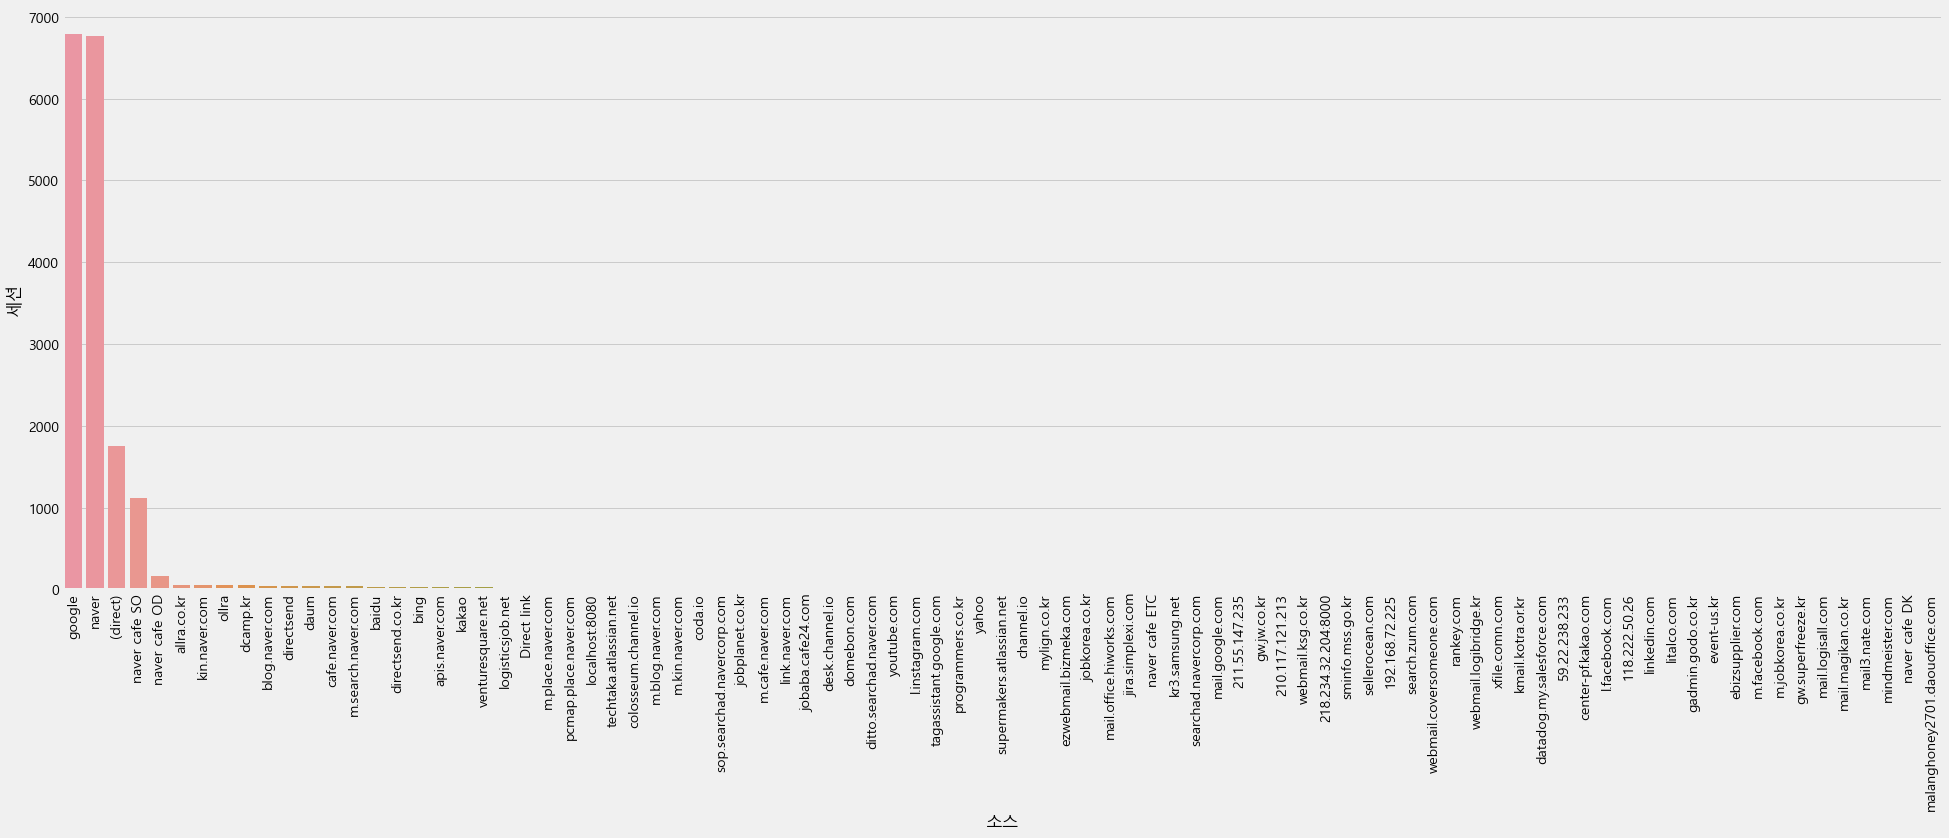

In [193]:
plt.figure(figsize=(30, 10))
sns.barplot(x='소스', y='세션', data=df.groupby('소스').sum().reset_index().sort_values('세션', ascending=False))
plt.xticks(rotation=90)
plt.show()

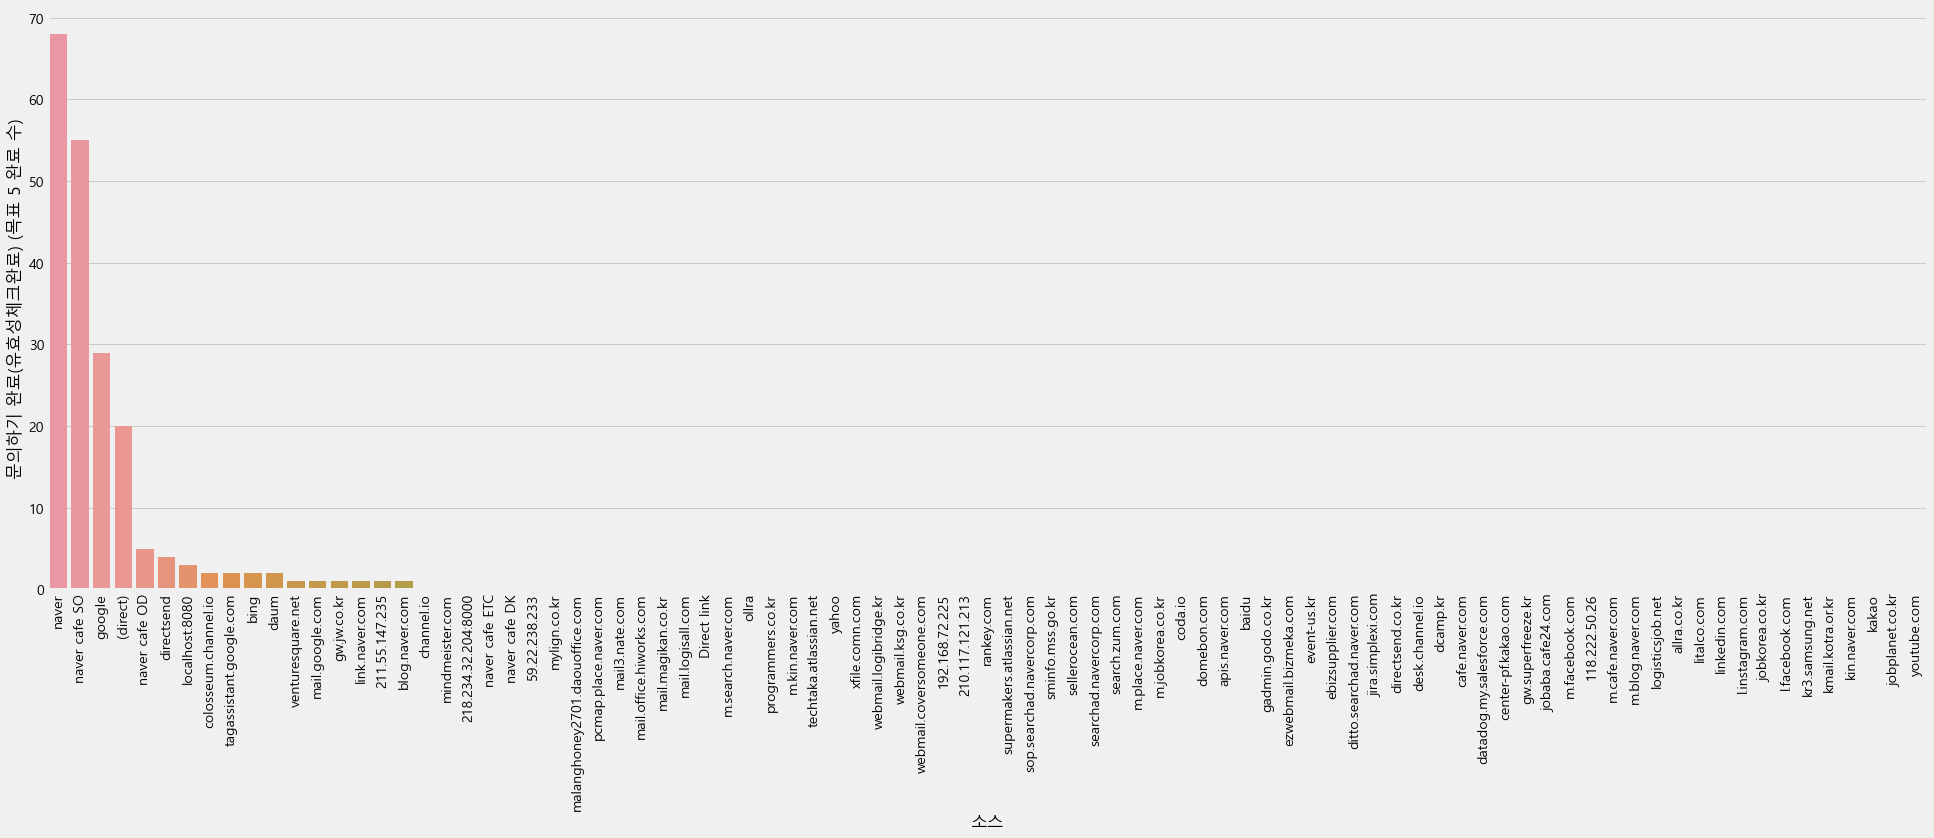

In [192]:
plt.figure(figsize=(30, 10))
sns.barplot(x='소스', y='문의하기 완료(유효성체크완료) (목표 5 완료 수)', data=df.groupby('소스').sum().reset_index().sort_values('문의하기 완료(유효성체크완료) (목표 5 완료 수)', ascending=False))
plt.xticks(rotation=90)
plt.show()

In [177]:
df[df['소스'] == 'navercafeDK']

,소스/매체,소스,매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
101,navercafeDK / etcposting,navercafeDK,etcposting,1,1,1,0.0,3.0,0.0,0.0,0,0.0


In [166]:
df['매체'].value_counts()

referral       73
organic         6
posting         5
etcposting      5
banner          3
fairposting     2
jobposting      2
reply           2
bizposting      2
open chat       2
message         2
Brochure        1
powerlink       1
leaflet         1
BrandSearch     1
(none)          1
youtube         1
cpc             1
mail            1
keywords        1
Name: 매체, dtype: int64

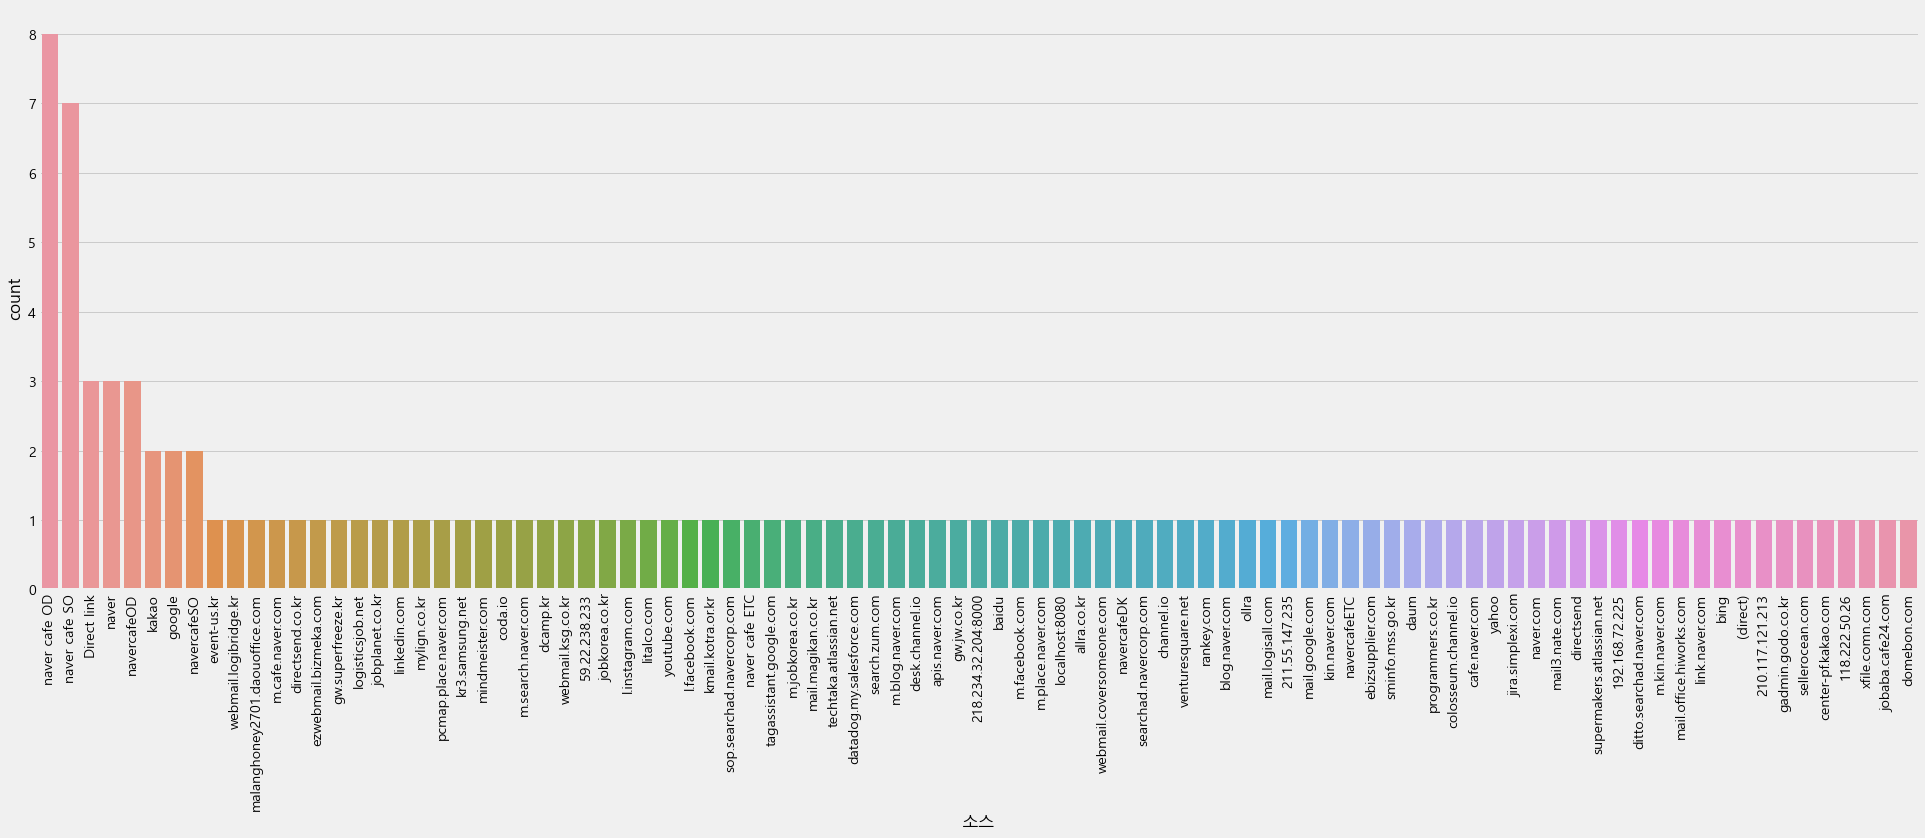

In [85]:
plt.figure(figsize=(30, 10))
sns.countplot(df.소스, order=df.소스.value_counts().index)
plt.xticks(rotation=90)
plt.show()

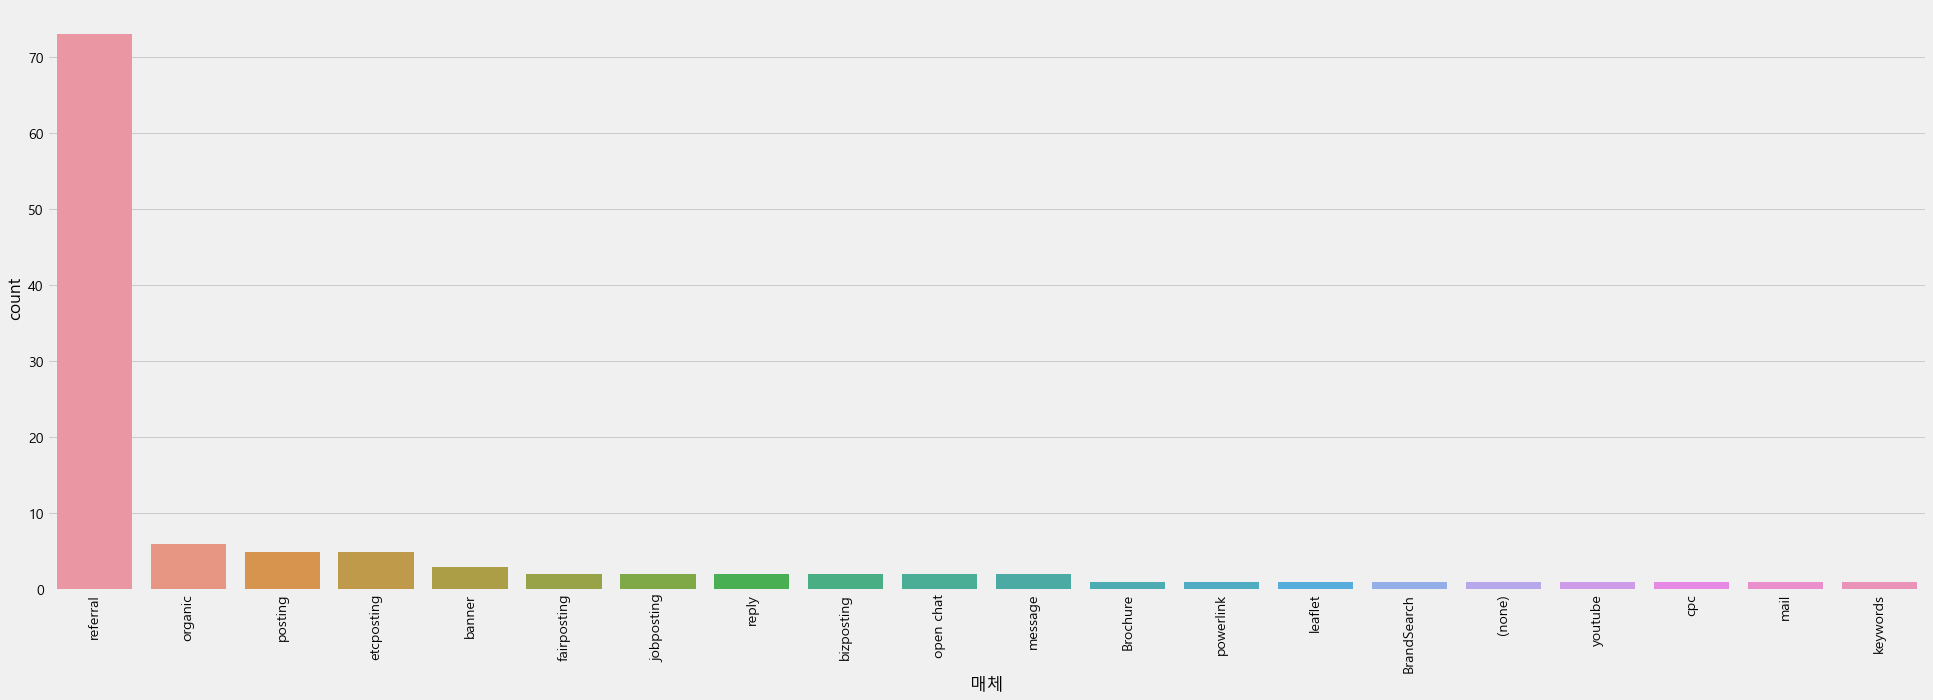

In [167]:
plt.figure(figsize=(30, 10))
sns.countplot(df.매체, order=df.매체.value_counts().index)
plt.xticks(rotation=90)
plt.show()

In [168]:
df.head()

,소스/매체,소스,매체,사용자,신규 방문자,세션,이탈률,세션당 페이지수,평균 세션 시간,문의하기 완료(유효성체크완료) (목표 5 전환율),문의하기 완료(유효성체크완료) (목표 5 완료 수),문의하기 완료(유효성체크완료) (목표 5 가치)
0,google / cpc,google,cpc,5051,4907,5921,78.16,1.66,49.29,0.32,19,0.0
1,naver / powerlink,naver,powerlink,4051,4006,4556,79.87,1.52,31.98,0.72,33,0.0
2,(direct) / (none),(direct),(none),1057,1021,1750,70.23,1.95,82.43,1.14,20,0.0
3,naver / organic,naver,organic,749,623,1017,50.25,2.77,123.73,1.18,12,0.0
4,google / organic,google,organic,598,493,868,58.29,2.53,143.01,1.15,10,0.0


## 구글애드 검색광고 실적(2021. 10. _ 12.)

In [2]:
df_google = pd.read_csv('./dataset/2. 구글애드 검색광고 실적(2021. 10. _ 12.) - 구글애드 검색광고 실적(2021. 10. _ 12.).csv', header=2)
df_google.head()

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,"8,279",5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,"20,330",1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,"45,469",0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,"43,989",0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,"30,842",0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%


In [3]:
df_google.shape

(21393, 16)

In [4]:
df_google.isnull().sum()

캠페인                    0
광고그룹                   0
검색 키워드                 0
Google 검색 키워드 검색 유형    0
통화 코드                  0
클릭수                    0
노출수                    0
클릭률(CTR)               0
평균 CPC                 0
비용                     0
노출수(절대 상단) %           0
노출수(상단) %              0
전환                     0
조회 후 전환                0
전환당비용                  0
전환율                    0
dtype: int64

In [5]:
df_google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21393 entries, 0 to 21392
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   캠페인                  21393 non-null  object
 1   광고그룹                 21393 non-null  object
 2   검색 키워드               21393 non-null  object
 3   Google 검색 키워드 검색 유형  21393 non-null  object
 4   통화 코드                21393 non-null  object
 5   클릭수                  21393 non-null  int64 
 6   노출수                  21393 non-null  object
 7   클릭률(CTR)             21393 non-null  object
 8   평균 CPC               21393 non-null  object
 9   비용                   21393 non-null  int64 
 10  노출수(절대 상단) %         21393 non-null  object
 11  노출수(상단) %            21393 non-null  object
 12  전환                   21393 non-null  int64 
 13  조회 후 전환              21393 non-null  int64 
 14  전환당비용                21393 non-null  object
 15  전환율                  21393 non-null  object
dtypes: i

In [6]:
for col in df_google.columns:
    print(f"column : {col}")
    print(f"The number of unique : {df_google[col].nunique()}")
    print()

column : 캠페인
The number of unique : 4

column : 광고그룹
The number of unique : 13

column : 검색 키워드
The number of unique : 8839

column : Google 검색 키워드 검색 유형
The number of unique : 3

column : 통화 코드
The number of unique : 1

column : 클릭수
The number of unique : 69

column : 노출수
The number of unique : 400

column : 클릭률(CTR)
The number of unique : 219

column : 평균 CPC
The number of unique : 143

column : 비용
The number of unique : 341

column : 노출수(절대 상단) %
The number of unique : 182

column : 노출수(상단) %
The number of unique : 269

column : 전환
The number of unique : 2

column : 조회 후 전환
The number of unique : 1

column : 전환당비용
The number of unique : 5

column : 전환율
The number of unique : 6



In [7]:
for col in ['캠페인', '광고그룹', 'Google 검색 키워드 검색 유형']:
    print(f"column : {col}")
    print(f"The number of unique : {df_google[col].unique()}")
    print()

column : 캠페인
The number of unique : ['1_브랜드 키워드' '2_주력 상품' '3_비주력 상품' '구글 검색어 광고 202106']

column : 광고그룹
The number of unique : ['①_브랜드 키워드' '②_드랍쉬핑' '②_택배' '④_냉장냉동' '①_풀필먼트' '①_창고' '③_3PL/4PL' '③_기타'
 '택배대행' '콜드체인' '풀필먼트' '드랍쉬핑' '3pl 4pl 물류대행']

column : Google 검색 키워드 검색 유형
The number of unique : ['확장검색' '구문검색' '일치검색']



In [8]:
df_google['캠페인'].value_counts()

1_브랜드 키워드           8075
구글 검색어 광고 202106    8020
3_비주력 상품            4449
2_주력 상품              849
Name: 캠페인, dtype: int64

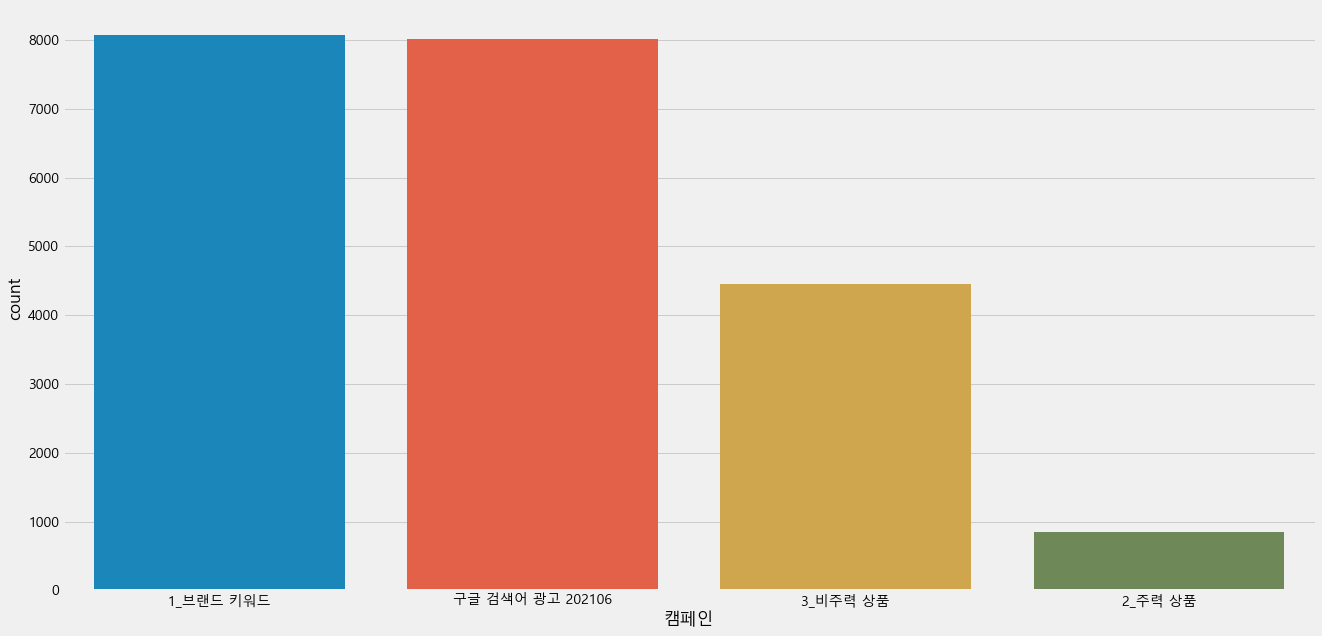

In [9]:
plt.figure(figsize=(20, 10))
sns.countplot(df_google.캠페인, order=df_google.캠페인.value_counts().index)
# plt.xticks(rotation=90)
plt.show()

In [16]:
df_google['광고그룹'].value_counts()

풀필먼트            11319
콜드체인             7462
택배대행             1284
①_풀필먼트            338
드랍쉬핑              320
③_기타              162
②_택배              132
②_드랍쉬핑            107
①_브랜드 키워드          90
①_창고               61
④_냉장냉동             47
③_3PL/4PL          36
3pl 4pl 물류대행       35
Name: 광고그룹, dtype: int64

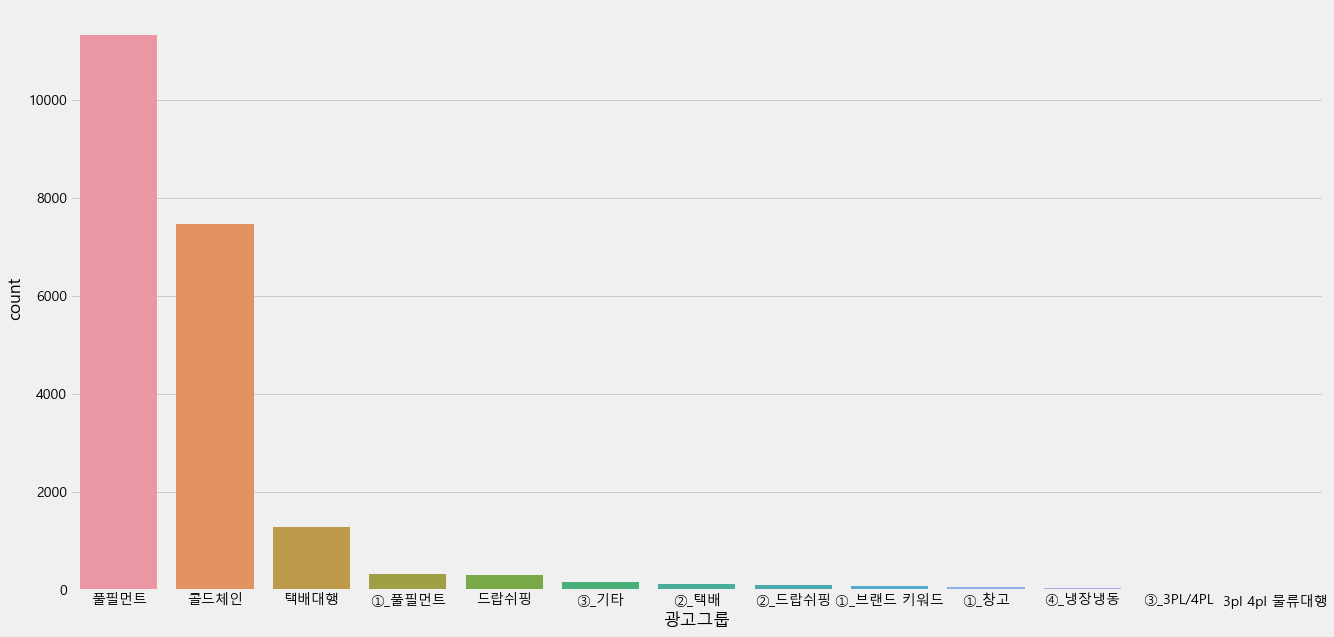

In [11]:
plt.figure(figsize=(20, 10))
sns.countplot(df_google.광고그룹, order=df_google.광고그룹.value_counts().index)
# plt.xticks(rotation=90)
plt.show()

In [12]:
df_google['Google 검색 키워드 검색 유형'].value_counts()

구문검색    11392
확장검색     9987
일치검색       14
Name: Google 검색 키워드 검색 유형, dtype: int64

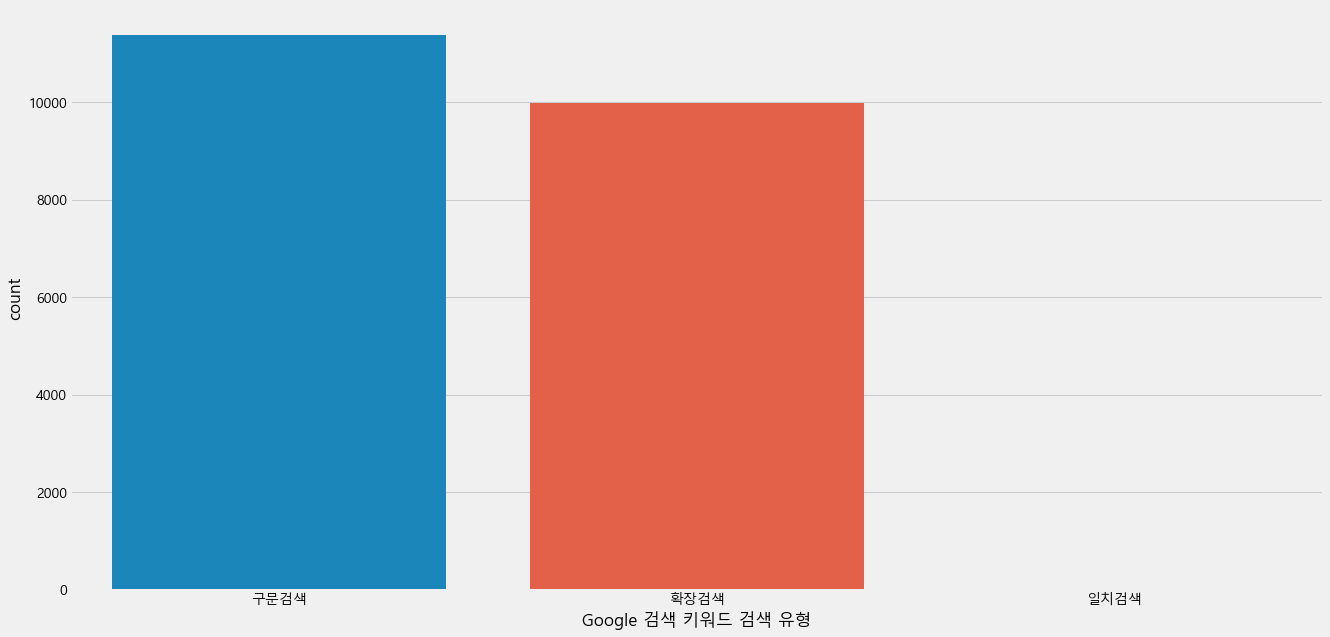

In [13]:
plt.figure(figsize=(20, 10))
sns.countplot(df_google['Google 검색 키워드 검색 유형'], order=df_google['Google 검색 키워드 검색 유형'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

### 클릭수 기준

In [14]:
df_google.sort_values('클릭수', ascending=False)

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,"8,279",5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,"20,330",1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,"45,469",0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,"43,989",0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,"30,842",0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7387,1_브랜드 키워드,콜드체인,한우 소고기 가격,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
7386,구글 검색어 광고 202106,콜드체인,참치 회 가격,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
7385,구글 검색어 광고 202106,콜드체인,이사 후기,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
7384,구글 검색어 광고 202106,콜드체인,굴삭기 기사 모집,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0


In [17]:
# 클릭수 0인 것
df_google[df_google['클릭수']==0]

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
388,1_브랜드 키워드,택배대행,고무 고무,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
389,구글 검색어 광고 202106,콜드체인,내일 배움 카드 학원 종류,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
390,구글 검색어 광고 202106,콜드체인,평생 교육,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
391,1_브랜드 키워드,풀필먼트,예쁜 집 인테리어,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0
392,1_브랜드 키워드,풀필먼트,옷장 정리,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21388,구글 검색어 광고 202106,콜드체인,견적서 양식,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21389,구글 검색어 광고 202106,콜드체인,물류대행,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21390,1_브랜드 키워드,콜드체인,공구 쇼핑몰,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21391,1_브랜드 키워드,풀필먼트,cnc 선반,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0


+ 21393개 중 21005개가 클릭수가 0이다.

### 노출수 기준

In [18]:
df_google['노출수'] = df_google['노출수'].str.replace(',', '').astype('int')

In [19]:
df_google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21393 entries, 0 to 21392
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   캠페인                  21393 non-null  object
 1   광고그룹                 21393 non-null  object
 2   검색 키워드               21393 non-null  object
 3   Google 검색 키워드 검색 유형  21393 non-null  object
 4   통화 코드                21393 non-null  object
 5   클릭수                  21393 non-null  int64 
 6   노출수                  21393 non-null  int32 
 7   클릭률(CTR)             21393 non-null  object
 8   평균 CPC               21393 non-null  object
 9   비용                   21393 non-null  int64 
 10  노출수(절대 상단) %         21393 non-null  object
 11  노출수(상단) %            21393 non-null  object
 12  전환                   21393 non-null  int64 
 13  조회 후 전환              21393 non-null  int64 
 14  전환당비용                21393 non-null  object
 15  전환율                  21393 non-null  object
dtypes: i

In [20]:
df_google[df_google['노출수']==0]

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
388,1_브랜드 키워드,택배대행,고무 고무,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
389,구글 검색어 광고 202106,콜드체인,내일 배움 카드 학원 종류,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
390,구글 검색어 광고 202106,콜드체인,평생 교육,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
391,1_브랜드 키워드,풀필먼트,예쁜 집 인테리어,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0
392,1_브랜드 키워드,풀필먼트,옷장 정리,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21388,구글 검색어 광고 202106,콜드체인,견적서 양식,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21389,구글 검색어 광고 202106,콜드체인,물류대행,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21390,1_브랜드 키워드,콜드체인,공구 쇼핑몰,확장검색,KRW,0,0,0,--,0,0,0,0,0,--,0
21391,1_브랜드 키워드,풀필먼트,cnc 선반,구문검색,KRW,0,0,0,--,0,0,0,0,0,--,0


+ 20625개 노출수 0

In [22]:
df_google_1 = df_google[df_google['노출수']>0]
df_google_1

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,8279,5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,20330,1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,45469,0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,43989,0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,30842,0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17830,2_주력 상품,①_풀필먼트,이커머스,일치검색,KRW,0,1,0.00%,--,0,0.00%,100.00%,0,0,--,0
17831,2_주력 상품,④_냉장냉동,냉장냉동 창고,확장검색,KRW,0,39,0.00%,--,0,0.00%,0.00%,0,0,--,0
17839,2_주력 상품,①_풀필먼트,DM발송,일치검색,KRW,0,1,0.00%,--,0,0,0,0,0,--,0
17840,2_주력 상품,①_풀필먼트,냉동물류창고,일치검색,KRW,0,2,0.00%,--,0,0.00%,0.00%,0,0,--,0


+ 노출수가 몇부터 유의미한 결과를 가질까

In [23]:
df_google_1.describe()

,클릭수,노출수,비용,전환,조회 후 전환
count,768.000000,768.000000,768.000000,768.000000,768.0
mean,8.710938,888.565104,2173.921875,0.005208,0.0
std,32.946874,3543.709973,7844.183083,0.072028,0.0
min,0.000000,1.000000,0.000000,0.000000,0.0
25%,0.000000,16.000000,0.000000,0.000000,0.0
50%,1.000000,87.000000,140.500000,0.000000,0.0
75%,3.250000,391.250000,850.000000,0.000000,0.0
max,439.000000,45469.000000,108856.000000,1.000000,0.0


In [24]:
df_google_1['노출수'].median()

87.0

### 클릭수 10이상

In [36]:
df_c = df_google[df_google['클릭수'] > 0]
df_c

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,8279,5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,20330,1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,45469,0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,43989,0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,30842,0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,2_주력 상품,①_풀필먼트,물류창고가격,확장검색,KRW,1,30,3.33%,265,265,0.00%,37.50%,0,0,--,0.00%
384,2_주력 상품,①_풀필먼트,물류 자동화 설비,확장검색,KRW,1,115,0.87%,260,260,0.00%,0.00%,0,0,--,0.00%
385,2_주력 상품,②_드랍쉬핑,드롭쉬핑,확장검색,KRW,1,15,6.67%,196,196,0.00%,18.18%,0,0,--,0.00%
386,2_주력 상품,①_풀필먼트,신선배송,확장검색,KRW,1,1,100.00%,234,234,0.00%,0.00%,0,0,--,0.00%


In [38]:
df_c['클릭수'].median()

3.0

In [43]:
df_gc10 = df_google[df_google['클릭수']>9]
df_gc10

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,8279,5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,20330,1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,45469,0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,43989,0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,30842,0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,2_주력 상품,①_풀필먼트,자동물류창고,확장검색,KRW,10,574,1.74%,242,2418,0.00%,5.59%,0,0,--,0.00%
105,2_주력 상품,④_냉장냉동,스티로폼 박스 가격,확장검색,KRW,10,183,5.46%,276,2762,10.38%,59.43%,0,0,--,0.00%
106,2_주력 상품,③_3PL/4PL,3PL물류업체,확장검색,KRW,10,226,4.42%,265,2653,0.98%,13.66%,0,0,--,0.00%
107,2_주력 상품,①_풀필먼트,E커머스,확장검색,KRW,10,879,1.14%,247,2466,2.44%,31.22%,0,0,--,0.00%


In [124]:
df_gc10.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 109 entries, 0 to 108
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   캠페인                  109 non-null    object
 1   광고그룹                 109 non-null    object
 2   검색 키워드               109 non-null    object
 3   Google 검색 키워드 검색 유형  109 non-null    object
 4   통화 코드                109 non-null    object
 5   클릭수                  109 non-null    int64 
 6   노출수                  109 non-null    int32 
 7   클릭률(CTR)             109 non-null    object
 8   평균 CPC               109 non-null    object
 9   비용                   109 non-null    int64 
 10  노출수(절대 상단) %         109 non-null    object
 11  노출수(상단) %            109 non-null    object
 12  전환                   109 non-null    int64 
 13  조회 후 전환              109 non-null    int64 
 14  전환당비용                109 non-null    object
 15  전환율                  109 non-null    object
dtypes: int32

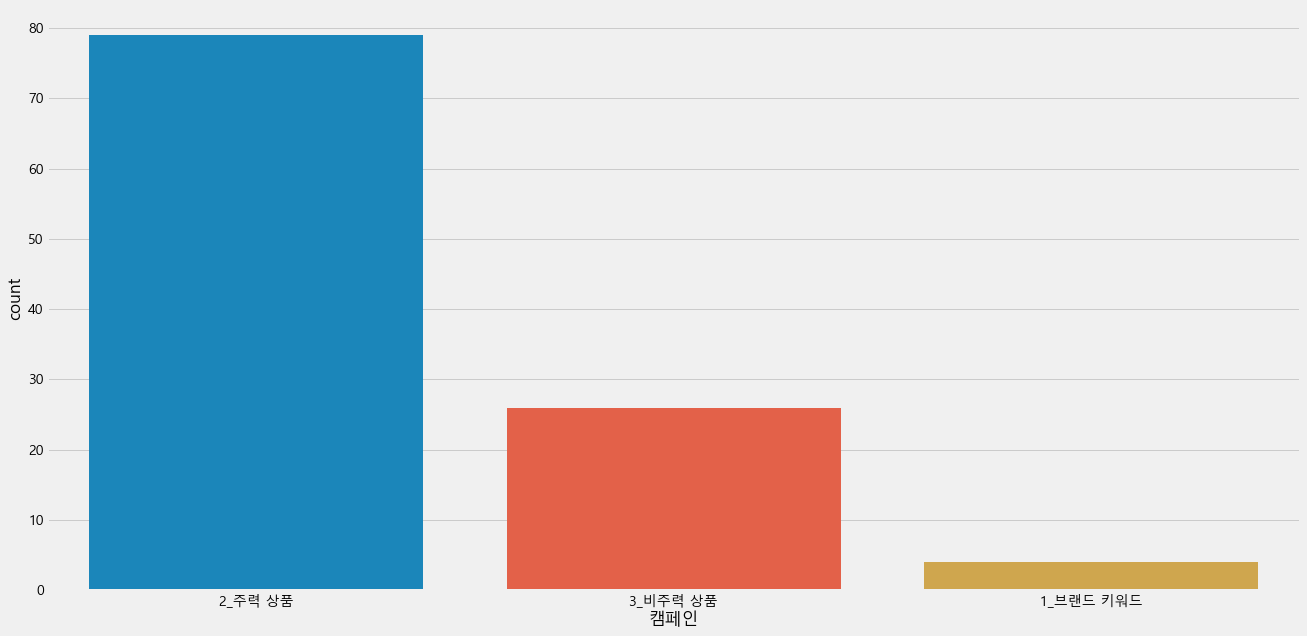

In [44]:
# 캠페인
plt.figure(figsize=(20, 10))
sns.countplot(df_gc10.캠페인, order=df_gc10.캠페인.value_counts().index)
# plt.xticks(rotation=90)
plt.show()

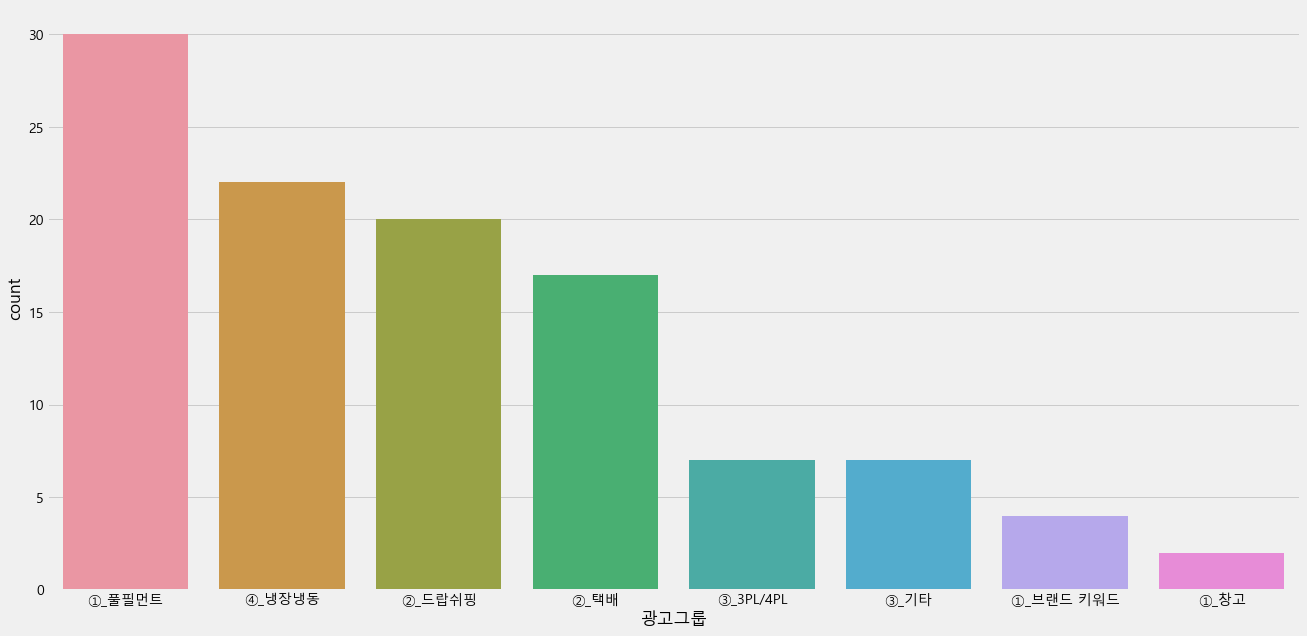

In [45]:
# 광고그룹
plt.figure(figsize=(20, 10))
sns.countplot(df_gc10.광고그룹, order=df_gc10.광고그룹.value_counts().index)
# plt.xticks(rotation=90)
plt.show()

In [50]:
# 키워드
df_gc10['검색 키워드'].nunique()

107

In [51]:
df_gc10['검색 키워드'].value_counts()

풀필먼트       2
택배대행       2
피킹         1
STORAGE    1
물류센터       1
          ..
3PL업체      1
자동물류창고     1
상품         1
저온창고가격     1
물류         1
Name: 검색 키워드, Length: 107, dtype: int64

In [52]:
df_gc10.groupby('캠페인').mean()

,클릭수,노출수,비용,전환,조회 후 전환
캠페인,,,,,
1_브랜드 키워드,181.250000,2283.750000,29669.250000,0.000000,0.0
2_주력 상품,50.265823,4906.518987,12436.379747,0.025316,0.0
3_비주력 상품,44.961538,5977.923077,13582.153846,0.038462,0.0


In [53]:
df_gc10.groupby(['캠페인', '광고그룹']).mean()

클릭수           노출수            비용        전환  조회 후 전환
캠페인       광고그룹                                                                
1_브랜드 키워드 ①_브랜드 키워드  181.250000   2283.750000  29669.250000  0.000000      0.0
2_주력 상품   ①_풀필먼트      42.966667   4637.233333   9837.733333  0.000000      0.0
          ②_드랍쉬핑      74.050000   6953.950000  19241.850000  0.000000      0.0
          ③_3PL/4PL   30.285714    932.285714   7489.571429  0.142857      0.0
          ④_냉장냉동      44.954545   4676.954545  11367.181818  0.045455      0.0
3_비주력 상품  ①_창고       110.500000  11778.000000  31070.000000  0.000000      0.0
          ②_택배        44.823529   5862.000000  13985.470588  0.000000      0.0
          ③_기타        26.571429   4602.285714   7606.142857  0.142857      0.0

In [134]:
df_gg = df_gc10.groupby(['캠페인', '광고그룹']).sum()
df_gg

클릭수     노출수      비용  전환  조회 후 전환
캠페인       광고그룹                                        
1_브랜드 키워드 ①_브랜드 키워드   725    9135  118677   0        0
2_주력 상품   ①_풀필먼트     1289  139117  295132   0        0
          ②_드랍쉬핑     1481  139079  384837   0        0
          ③_3PL/4PL   212    6526   52427   1        0
          ④_냉장냉동      989  102893  250078   1        0
3_비주력 상품  ①_창고        221   23556   62140   0        0
          ②_택배        762   99654  237753   0        0
          ③_기타        186   32216   53243   1        0

In [135]:
df_gg['비용'] / df_gg['클릭수']

캠페인        광고그룹     
1_브랜드 키워드  ①_브랜드 키워드    163.692414
2_주력 상품    ①_풀필먼트       228.961986
           ②_드랍쉬핑       259.849426
           ③_3PL/4PL    247.297170
           ④_냉장냉동       252.859454
3_비주력 상품   ①_창고         281.176471
           ②_택배         312.011811
           ③_기타         286.252688
dtype: float64

In [136]:
# CPC 컬럼 추가
df_gg['CPC'] = np.nan
df_gg['CPC'] = df_gg['비용'] / df_gg['클릭수']
df_gg


클릭수     노출수      비용  전환  조회 후 전환         CPC
캠페인       광고그룹                                                    
1_브랜드 키워드 ①_브랜드 키워드   725    9135  118677   0        0  163.692414
2_주력 상품   ①_풀필먼트     1289  139117  295132   0        0  228.961986
          ②_드랍쉬핑     1481  139079  384837   0        0  259.849426
          ③_3PL/4PL   212    6526   52427   1        0  247.297170
          ④_냉장냉동      989  102893  250078   1        0  252.859454
3_비주력 상품  ①_창고        221   23556   62140   0        0  281.176471
          ②_택배        762   99654  237753   0        0  312.011811
          ③_기타        186   32216   53243   1        0  286.252688

In [137]:
df_gc10

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,8279,5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,20330,1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,45469,0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,43989,0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,30842,0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,2_주력 상품,①_풀필먼트,자동물류창고,확장검색,KRW,10,574,1.74%,242,2418,0.00%,5.59%,0,0,--,0.00%
105,2_주력 상품,④_냉장냉동,스티로폼 박스 가격,확장검색,KRW,10,183,5.46%,276,2762,10.38%,59.43%,0,0,--,0.00%
106,2_주력 상품,③_3PL/4PL,3PL물류업체,확장검색,KRW,10,226,4.42%,265,2653,0.98%,13.66%,0,0,--,0.00%
107,2_주력 상품,①_풀필먼트,E커머스,확장검색,KRW,10,879,1.14%,247,2466,2.44%,31.22%,0,0,--,0.00%


In [ ]:
df_by_group_label = df.groupby(['group','label'])['xval'].sum().reset_index()
sns.barplot(x='group', y='xval', hue='label',data=df_by_group_label )

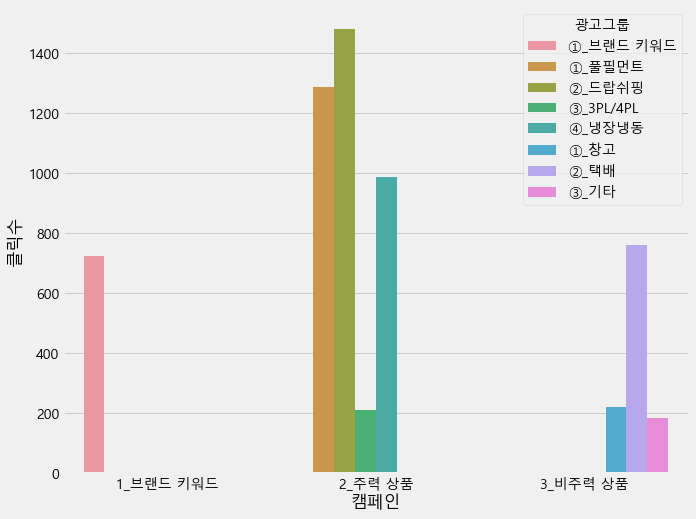

In [142]:
plt.figure(figsize=(10, 8))
df_by_group_label = df_gc10.groupby(['캠페인','광고그룹'])['클릭수'].sum().reset_index()
sns.barplot(x='캠페인', y='클릭수', hue='광고그룹', data=df_by_group_label )
plt.show()

In [196]:
df_gc10.sort_values('클릭수', ascending=False).head(20)

,캠페인,광고그룹,검색 키워드,Google 검색 키워드 검색 유형,통화 코드,클릭수,노출수,클릭률(CTR),평균 CPC,비용,노출수(절대 상단) %,노출수(상단) %,전환,조회 후 전환,전환당비용,전환율
0,1_브랜드 키워드,①_브랜드 키워드,'콜로세움',확장검색,KRW,439,8279,5.30%,145,63511,82.38%,94.81%,0,0,--,0.00%
1,2_주력 상품,②_드랍쉬핑,해외직구,확장검색,KRW,404,20330,1.99%,269,108856,7.63%,83.20%,0,0,--,0.00%
2,2_주력 상품,②_드랍쉬핑,알리직구,확장검색,KRW,219,45469,0.48%,253,55451,3.34%,95.85%,0,0,--,0.00%
3,3_비주력 상품,②_택배,택배,확장검색,KRW,213,43989,0.48%,295,62764,10.38%,59.10%,0,0,--,0.00%
4,2_주력 상품,④_냉장냉동,컬리배송,확장검색,KRW,209,30842,0.68%,250,52234,1.01%,95.06%,0,0,--,0.00%
5,2_주력 상품,①_풀필먼트,상품,확장검색,KRW,206,14494,1.42%,187,38553,11.53%,38.82%,0,0,--,0.00%
6,3_비주력 상품,①_창고,'창고',확장검색,KRW,191,21807,0.88%,284,54248,2.47%,26.04%,0,0,--,0.00%
7,1_브랜드 키워드,①_브랜드 키워드,콜로세움코퍼레이션,구문검색,KRW,189,626,30.19%,119,22406,79.67%,93.72%,0,0,--,0.00%
8,2_주력 상품,②_드랍쉬핑,도매업,확장검색,KRW,173,7254,2.38%,235,40595,2.31%,29.62%,0,0,--,0.00%
9,2_주력 상품,①_풀필먼트,물류,확장검색,KRW,171,24354,0.70%,245,41816,2.79%,20.41%,0,0,--,0.00%


In [123]:
# 109
df_gc10['클릭수'].sum()

5865

In [121]:
# 21284
df_google[df_google['클릭수']<10]['클릭수'].sum()

825

## 네이버 검색광고 실적(2021. 10. _ 12.)

In [55]:
df_n = pd.read_csv('./dataset/3. 네이버 검색광고 실적(2021. 10. _ 12.) - 네이버 검색광고 실적(2021. 10. _ 12.).csv', header=1)
df_n

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
0,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,11번가물류,43,0,0.00,0,0,1.6,0,0.0,0
1,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류,10,0,0.00,0,0,21.4,0,0.0,0
2,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류견적,404,0,0.00,0,0,5.5,0,0.0,0
3,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류대행,708,0,0.00,0,0,11.1,0,0.0,0
4,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류비용,657,0,0.00,0,0,9.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5114,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움이커머스,1,1,100.00,0,0,1.0,0,0.0,0
5115,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움창고,1,1,100.00,0,0,1.0,0,0.0,0
5116,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움코퍼레이션,51,15,29.42,0,0,1.0,0,0.0,0
5117,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움풀필먼트,47,9,19.15,0,0,1.0,0,0.0,0


In [56]:
df_n.shape

(5119, 14)

In [57]:
df_n.isnull().sum()

캠페인유형              0
캠페인                0
광고그룹               0
소재                 0
키워드                0
노출수                0
클릭수                0
클릭률(%)             0
평균클릭비용(VAT포함,원)    0
총비용(VAT포함,원)       0
평균노출순위             0
전환수                0
전환율(%)             0
전환당비용(원)           0
dtype: int64

In [58]:
for col in df_n.columns:
    print(f"column : {col}")
    print(f"The number of unique : {df_n[col].nunique()}")
    print()

column : 캠페인유형
The number of unique : 2

column : 캠페인
The number of unique : 3

column : 광고그룹
The number of unique : 8

column : 소재
The number of unique : 47

column : 키워드
The number of unique : 1176

column : 노출수
The number of unique : 898

column : 클릭수
The number of unique : 47

column : 클릭률(%)
The number of unique : 240

column : 평균클릭비용(VAT포함,원)
The number of unique : 307

column : 총비용(VAT포함,원)
The number of unique : 300

column : 평균노출순위
The number of unique : 386

column : 전환수
The number of unique : 3

column : 전환율(%)
The number of unique : 21

column : 전환당비용(원)
The number of unique : 22



In [59]:
for col in ['캠페인유형', '캠페인', '광고그룹', '소재']:
    print(f"column : {col}")
    print(f"The number of unique : {df_n[col].unique()}")
    print()

column : 캠페인유형
The number of unique : ['파워링크' '브랜드검색']

column : 캠페인
The number of unique : ['2_주력 상품' '3_비주력 상품' '브랜드검색#1_PC']

column : 광고그룹
The number of unique : ['①_풀필먼트' '②_드랍쉬핑' '③_3PL/4PL' '④_냉장냉동' '①_창고' '②_택배' '③_기타'
 '4_브랜드 검색_PC(UTM삽입)']

column : 소재
The number of unique : ['nad-a001-01-000000152214505' 'nad-a001-01-000000152214525'
 'nad-a001-01-000000152214552' 'nad-a001-01-000000152214572'
 'nad-a001-01-000000152214856' 'nad-a001-01-000000152214940'
 'nad-a001-01-000000152214956' 'nad-a001-01-000000152214983'
 'nad-a001-01-000000152214993' 'nad-a001-01-000000152215155'
 'nad-a001-01-000000152215209' 'nad-a001-01-000000152215271'
 'nad-a001-01-000000152215280' 'nad-a001-01-000000152215298'
 'nad-a001-01-000000152215320' 'nad-a001-01-000000152215459(삭제)'
 'nad-a001-01-000000152215474' 'nad-a001-01-000000152215538'
 'nad-a001-01-000000152215552' 'nad-a001-01-000000152215616'
 'nad-a001-01-000000159157452' 'nad-a001-01-000000152215715'
 'nad-a001-01-000000152215757' 'nad-a00

In [60]:
df_n['키워드'].value_counts()

콜로세움3PL      21
콜로세움풀필먼트     20
콜로세움코퍼레이션    19
콜로세움물류       17
냉동창고임대       11
             ..
기업3자물류        1
제3자물류비용       1
온라인3PL        1
SCM           1
KPP           1
Name: 키워드, Length: 1176, dtype: int64

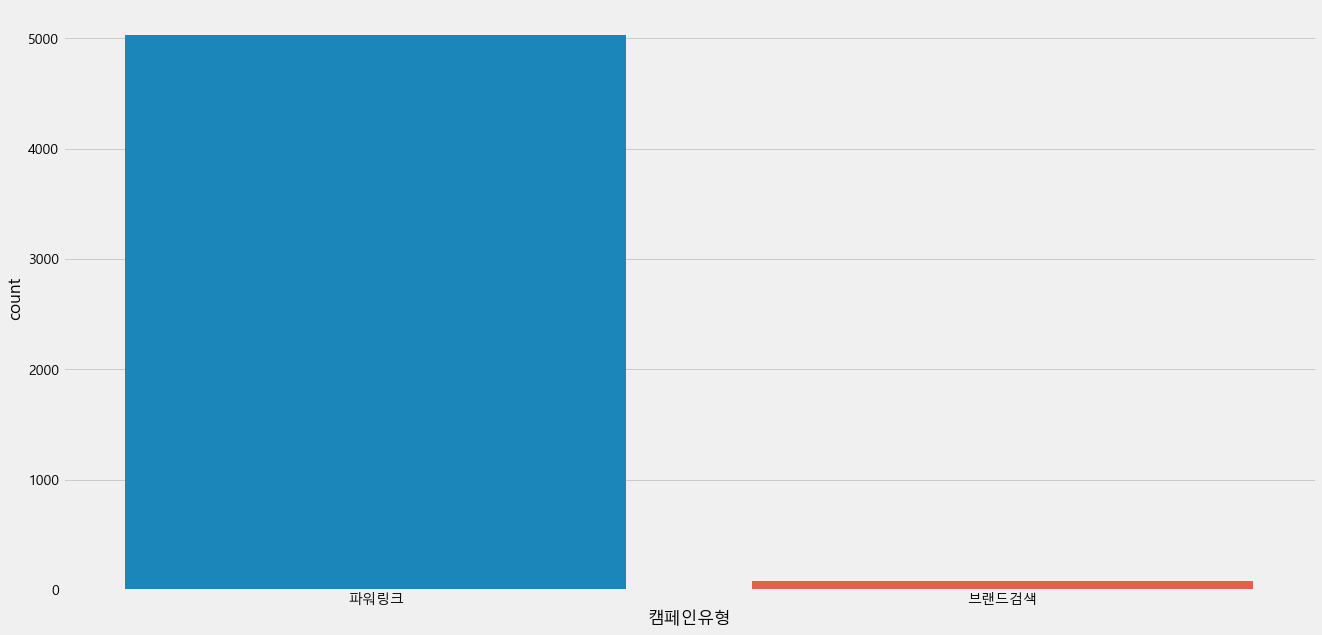

In [61]:
plt.figure(figsize=(20, 10))
sns.countplot(df_n['캠페인유형'], order=df_n['캠페인유형'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

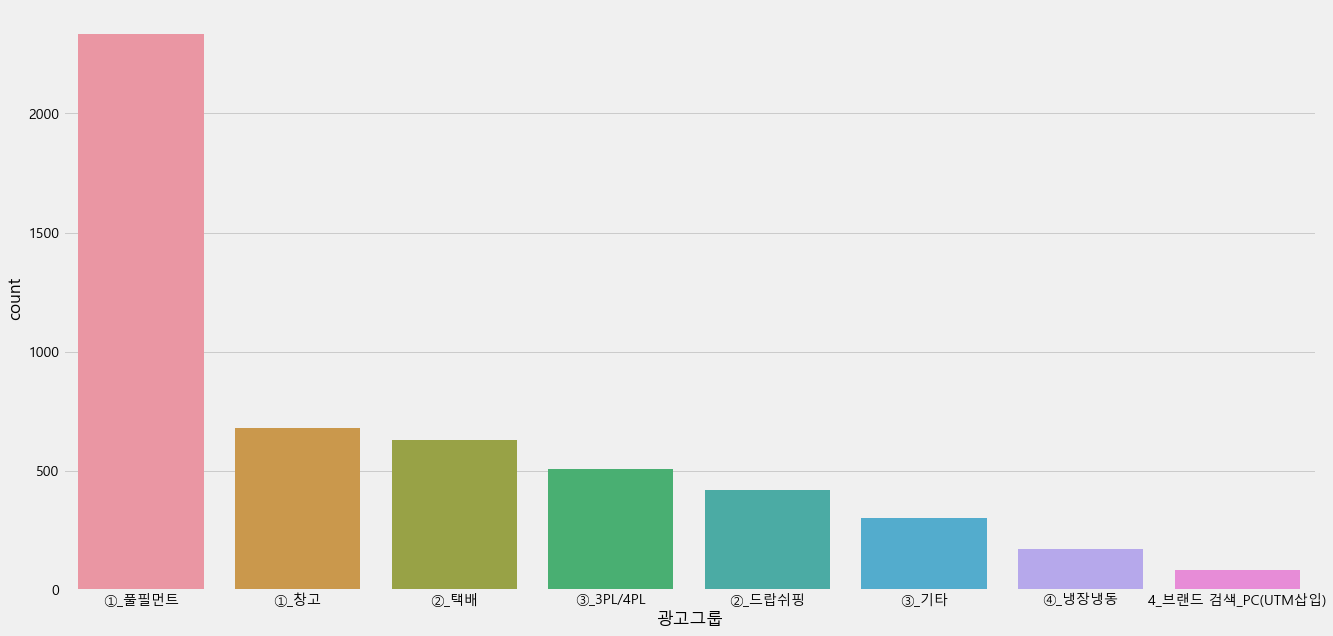

In [62]:
plt.figure(figsize=(20, 10))
sns.countplot(df_n['광고그룹'], order=df_n['광고그룹'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

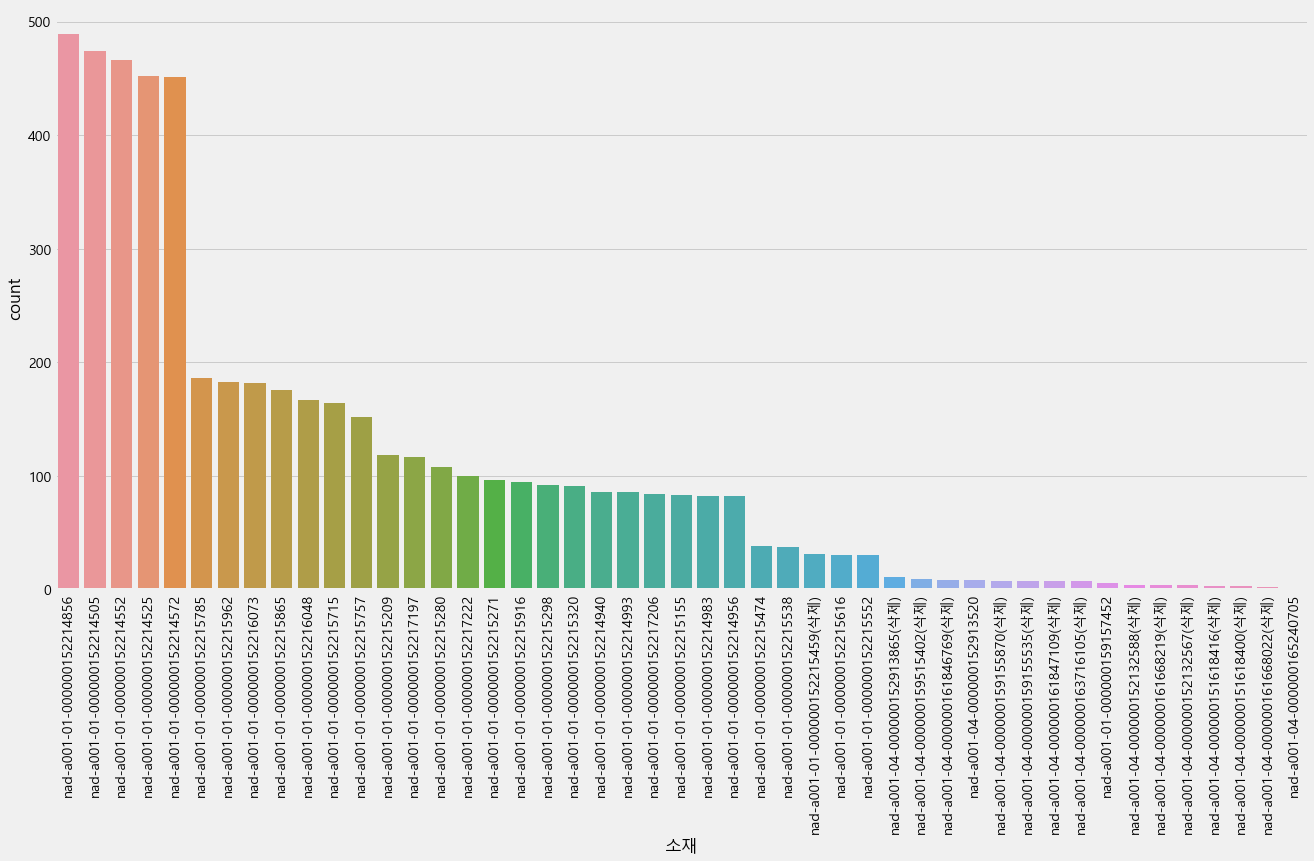

In [63]:
plt.figure(figsize=(20, 10))
sns.countplot(df_n['소재'], order=df_n['소재'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

### 클릭수 기준

In [64]:
df_n.describe()

,클릭수,클릭률(%),평균노출순위,전환수,전환율(%)
count,5119.000000,5119.000000,5119.000000,5119.000000,5119.000000
mean,0.815784,1.791393,8.504923,0.008791,0.304007
std,6.703182,10.311629,11.088636,0.097451,4.687035
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,2.100000,0.000000,0.000000
50%,0.000000,0.000000,5.200000,0.000000,0.000000
75%,0.000000,0.000000,11.500000,0.000000,0.000000
max,353.000000,100.000000,129.500000,2.000000,100.000000


In [65]:
df_n['클릭수'].median()

0.0

In [66]:
# 클릭수 0 제외하기
df_n[df_n['클릭수']>0]

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
11,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,B2C물류,22,1,4.55,110,110,11.7,0,0.0,0
13,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,DM발송업체,750,3,0.40,535,"1,606",6.1,0,0.0,0
16,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,LOGISTICS,"7,600",1,0.02,"1,100","1,100",2.5,0,0.0,0
22,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,가구물류,192,1,0.53,616,616,3.8,0,0.0,0
23,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,가구배송,"1,531",3,0.20,645,"1,936",4.4,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5114,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움이커머스,1,1,100.00,0,0,1.0,0,0.0,0
5115,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움창고,1,1,100.00,0,0,1.0,0,0.0,0
5116,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움코퍼레이션,51,15,29.42,0,0,1.0,0,0.0,0
5117,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움풀필먼트,47,9,19.15,0,0,1.0,0,0.0,0


In [72]:
# 클릭수 10이상
df_nc10 = df_n[df_n['클릭수']>9].reset_index(drop=True)
df_nc10

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
0,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,공유창고,"3,357",16,0.48,"1,135","18,161",4.2,0,0.00,0
1,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,풀필먼트,"1,730",10,0.58,"1,661","16,610",12.9,1,10.00,"16,610"
2,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214856,공유창고,"4,008",12,0.30,980,"11,759",4.2,0,0.00,0
3,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215715,송파창고,"31,102",11,0.04,430,"4,730",1.6,0,0.00,0
4,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215757,송파창고,"26,547",10,0.04,407,"4,070",1.6,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000161847109(삭제),콜로세움코퍼레이션,51,14,27.46,0,0,1.0,0,0.00,0
76,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000161847109(삭제),콜로세움풀필먼트,80,24,30.00,0,0,1.0,0,0.00,0
77,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움3PL,13,10,76.93,0,0,1.0,1,10.00,0
78,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움물류,30,18,60.00,0,0,1.0,1,5.56,0


In [73]:
df_nc10

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
0,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,공유창고,"3,357",16,0.48,"1,135","18,161",4.2,0,0.00,0
1,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,풀필먼트,"1,730",10,0.58,"1,661","16,610",12.9,1,10.00,"16,610"
2,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214856,공유창고,"4,008",12,0.30,980,"11,759",4.2,0,0.00,0
3,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215715,송파창고,"31,102",11,0.04,430,"4,730",1.6,0,0.00,0
4,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215757,송파창고,"26,547",10,0.04,407,"4,070",1.6,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000161847109(삭제),콜로세움코퍼레이션,51,14,27.46,0,0,1.0,0,0.00,0
76,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000161847109(삭제),콜로세움풀필먼트,80,24,30.00,0,0,1.0,0,0.00,0
77,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움3PL,13,10,76.93,0,0,1.0,1,10.00,0
78,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움물류,30,18,60.00,0,0,1.0,1,5.56,0


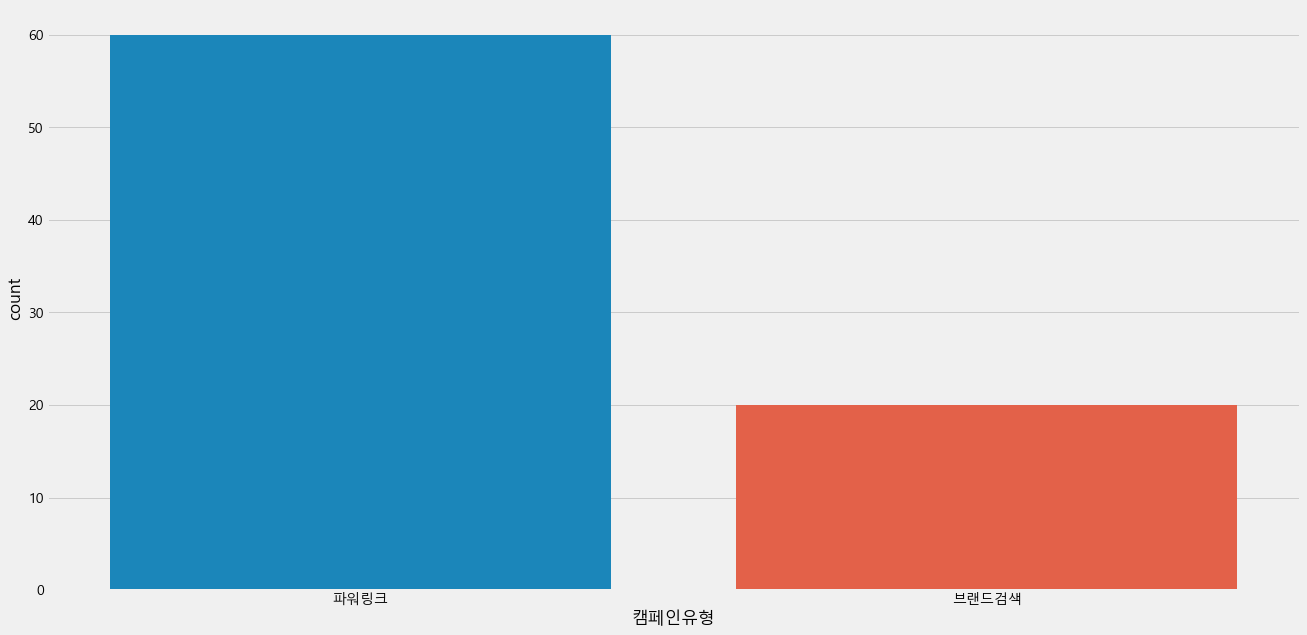

In [74]:
plt.figure(figsize=(20, 10))
sns.countplot(df_nc10['캠페인유형'], order=df_nc10['캠페인유형'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

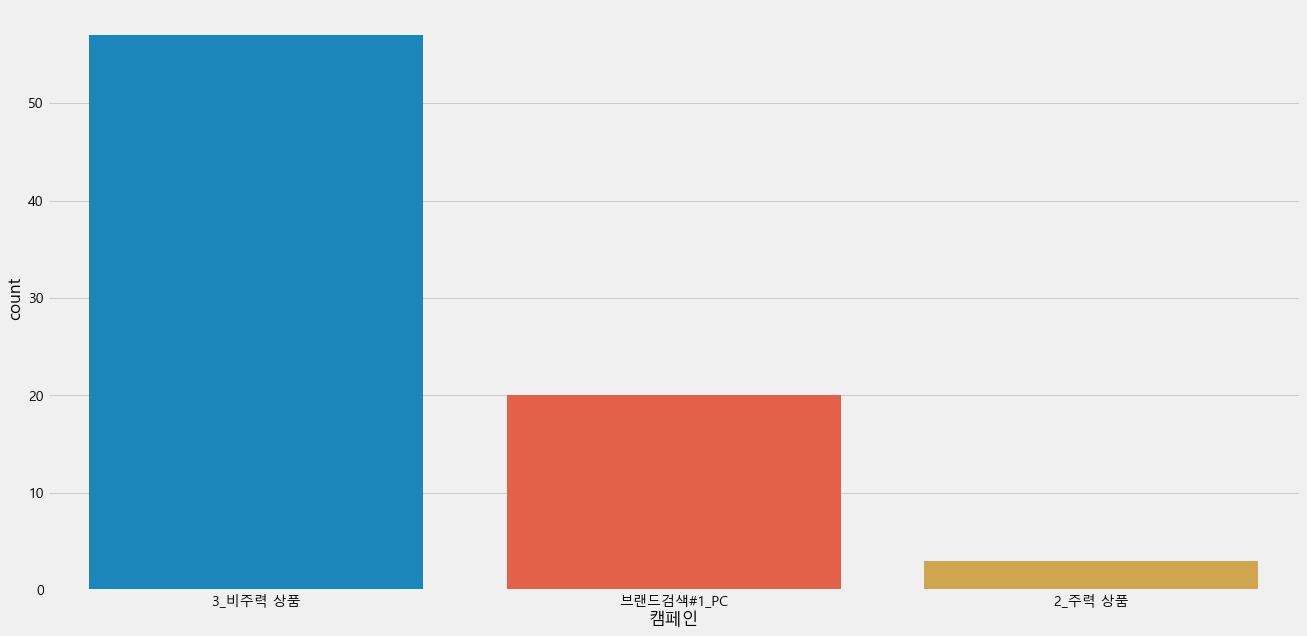

In [75]:
plt.figure(figsize=(20, 10))
sns.countplot(df_nc10['캠페인'], order=df_nc10['캠페인'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

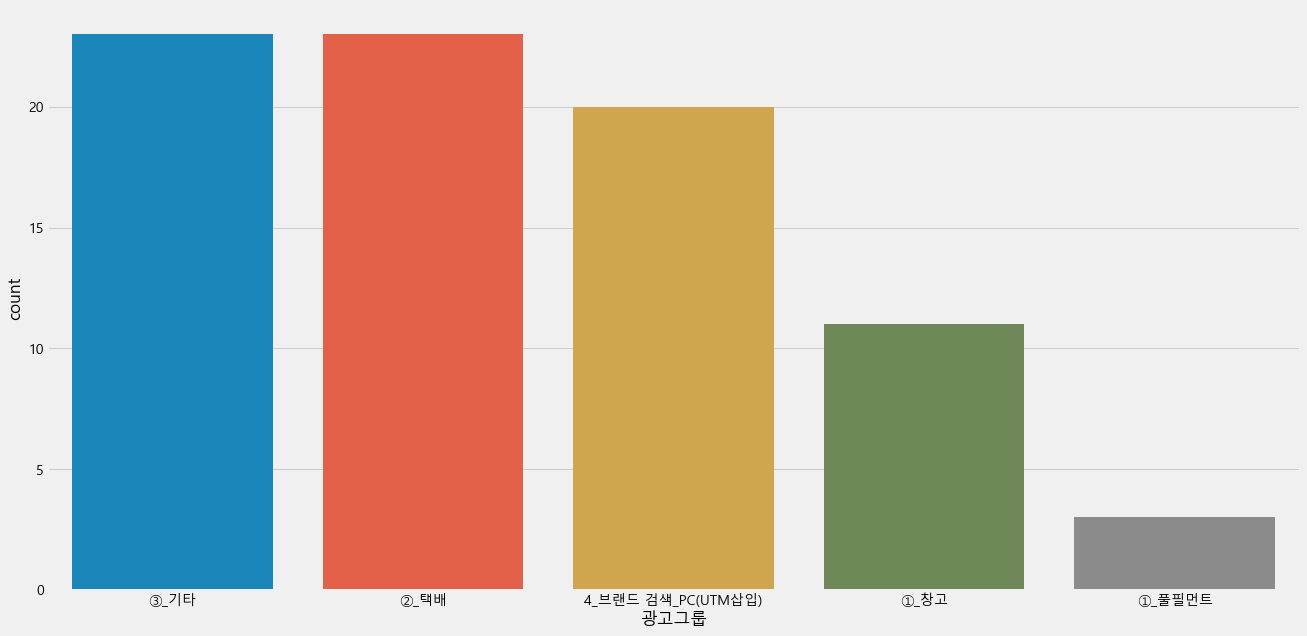

In [76]:
plt.figure(figsize=(20, 10))
sns.countplot(df_nc10['광고그룹'], order=df_nc10['광고그룹'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

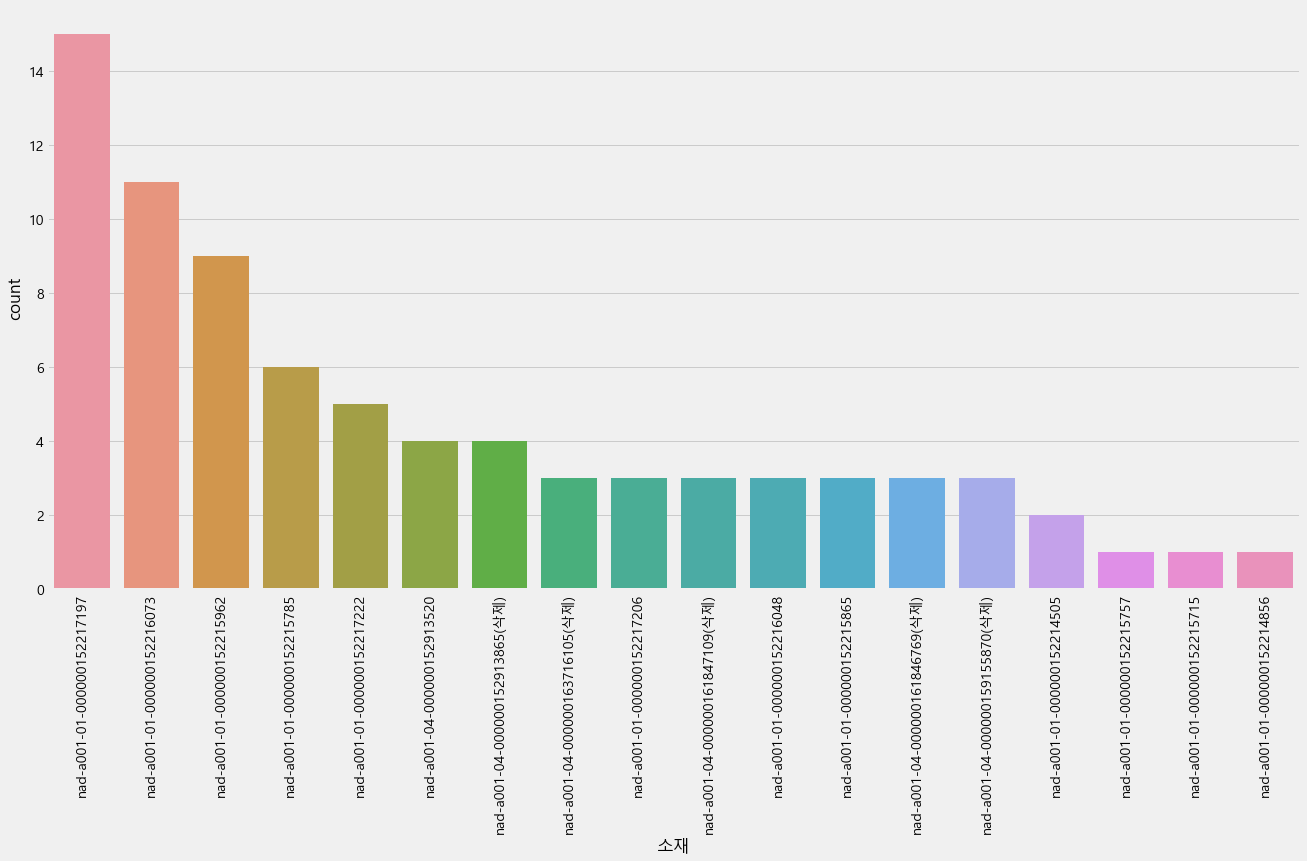

In [78]:
plt.figure(figsize=(20, 10))
sns.countplot(df_nc10['소재'], order=df_nc10['소재'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

In [79]:
df_nc10['키워드'].nunique()

39

In [80]:
df_nc10['키워드'].value_counts()

콜로세움물류       6
콜로세움코퍼레이션    6
콜로세움풀필먼트     4
콜로세움3PL      4
송파창고         4
방문택배         3
싸대기          3
하차           3
출고           3
택배           3
택배계약         3
국제택배         2
택배접수         2
남양주창고        2
공유창고         2
택배보내기        2
택배요금         2
맞팔           2
피킹           2
가구택배         2
택배방문접수       2
모두먼트         1
서이추          1
해외택배         1
고양창고         1
풀필먼트         1
적재           1
카톤박스         1
인천창고         1
상차           1
파주창고임대       1
입고           1
수송           1
택배사계약        1
물류센터임대       1
OMS          1
스큐           1
합포장          1
서울창고         1
Name: 키워드, dtype: int64

In [81]:
df_nc10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   캠페인유형            80 non-null     object 
 1   캠페인              80 non-null     object 
 2   광고그룹             80 non-null     object 
 3   소재               80 non-null     object 
 4   키워드              80 non-null     object 
 5   노출수              80 non-null     object 
 6   클릭수              80 non-null     int64  
 7   클릭률(%)           80 non-null     float64
 8   평균클릭비용(VAT포함,원)  80 non-null     object 
 9   총비용(VAT포함,원)     80 non-null     object 
 10  평균노출순위           80 non-null     float64
 11  전환수              80 non-null     int64  
 12  전환율(%)           80 non-null     float64
 13  전환당비용(원)         80 non-null     object 
dtypes: float64(3), int64(2), object(9)
memory usage: 8.9+ KB


In [91]:
df_nc10['전환당비용(원)'].str.replace(',', '').astype('int')

0         0
1     16610
2         0
3         0
4         0
      ...  
75        0
76        0
77        0
78        0
79        0
Name: 전환당비용(원), Length: 80, dtype: int32

In [93]:
# 숫자타입으로 변경
df_nc10['노출수'] = df_nc10['노출수'].str.replace(',', '').astype('int')
df_nc10['평균클릭비용(VAT포함,원)'] = df_nc10['평균클릭비용(VAT포함,원)'].str.replace(',', '').astype('int')
df_nc10['총비용(VAT포함,원)'] = df_nc10['총비용(VAT포함,원)'].str.replace(',', '').astype('int')
df_nc10['전환당비용(원)'] = df_nc10['전환당비용(원)'].str.replace(',', '').astype('int')

In [94]:
df_nc10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   캠페인유형            80 non-null     object 
 1   캠페인              80 non-null     object 
 2   광고그룹             80 non-null     object 
 3   소재               80 non-null     object 
 4   키워드              80 non-null     object 
 5   노출수              80 non-null     int32  
 6   클릭수              80 non-null     int64  
 7   클릭률(%)           80 non-null     float64
 8   평균클릭비용(VAT포함,원)  80 non-null     int32  
 9   총비용(VAT포함,원)     80 non-null     int32  
 10  평균노출순위           80 non-null     float64
 11  전환수              80 non-null     int64  
 12  전환율(%)           80 non-null     float64
 13  전환당비용(원)         80 non-null     int32  
dtypes: float64(3), int32(4), int64(2), object(5)
memory usage: 7.6+ KB


In [95]:
df_nc10.groupby('캠페인유형').mean()

,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
캠페인유형,,,,,,,,,
브랜드검색,64.300000,24.0,49.8295,0.0,0.000000,1.000000,0.650000,3.376500,0.000000
파워링크,95391.866667,33.6,0.3120,480.3,10215.883333,2.748333,0.033333,0.233333,699.966667


In [99]:
df_nc10.groupby(['캠페인유형', '캠페인', '광고그룹', '소재']).sum()

노출수  \
캠페인유형 캠페인        광고그룹               소재                                         
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520          480   
                                    nad-a001-04-000000152913865(삭제)      342   
                                    nad-a001-04-000000159155870(삭제)       79   
                                    nad-a001-04-000000161846769(삭제)      141   
                                    nad-a001-04-000000161847109(삭제)      150   
                                    nad-a001-04-000000163716105(삭제)       94   
파워링크  2_주력 상품    ①_풀필먼트             nad-a001-01-000000152214505         5087   
                                    nad-a001-01-000000152214856         4008   
      3_비주력 상품   ①_창고               nad-a001-01-000000152215715        31102   
                                    nad-a001-01-000000152215757        26547   
                                    nad-a001-01-000000152215785       274636   
                                    nad-a001-01-000000152215865       298565   
                 ②_택배               nad-a001-01-000000152215962       341298   
                                    nad-a001-01-000000152216048        82528   
                                    nad-a001-01-000000152216073       365939   
                 ③_기타               nad-a001-01-000000152217197      3369451   
                                    nad-a001-01-000000152217206       286469   
                                    nad-a001-01-000000152217222       637882   

                                                                     클릭수  \
캠페인유형 캠페인        광고그룹               소재                                     
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520      176   
                                    nad-a001-04-000000152913865(삭제)  126   
                                    nad-a001-04-000000159155870(삭제)   40   
                                    nad-a001-04-000000161846769(삭제)   43   
                                    nad-a001-04-000000161847109(삭제)   52   
                                    nad-a001-04-000000163716105(삭제)   43   
파워링크  2_주력 상품    ①_풀필먼트             nad-a001-01-000000152214505       26   
                                    nad-a001-01-000000152214856       12   
      3_비주력 상품   ①_창고               nad-a001-01-000000152215715       11   
                                    nad-a001-01-000000152215757       10   
                                    nad-a001-01-000000152215785      133   
                                    nad-a001-01-000000152215865       95   
                 ②_택배               nad-a001-01-000000152215962      198   
                                    nad-a001-01-000000152216048       50   
                                    nad-a001-01-000000152216073      290   
                 ③_기타               nad-a001-01-000000152217197      931   
                                    nad-a001-01-000000152217206       80   
                                    nad-a001-01-000000152217222      180   

                                                                     클릭률(%)  \
캠페인유형 캠페인        광고그룹               소재                                        
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520      182.43   
                                    nad-a001-04-000000152913865(삭제)  198.74   
                                    nad-a001-04-000000159155870(삭제)  197.16   
                                    nad-a001-04-000000161846769(삭제)  120.76   
                                    nad-a001-04-000000161847109(삭제)  131.15   
                                    nad-a001-04-000000163716105(삭제)  166.35   
파워링크  2_주력 상품    ①_풀필먼트             nad-a001-01-000000152214505        1.06   
                                    nad-a001-01-000000152214856        0.30   
      3_비주력 상품   ①_창고               nad-a001-01-000000152215715        0.04   
                                    nad-a001-01-000000152215757        0.04   
   

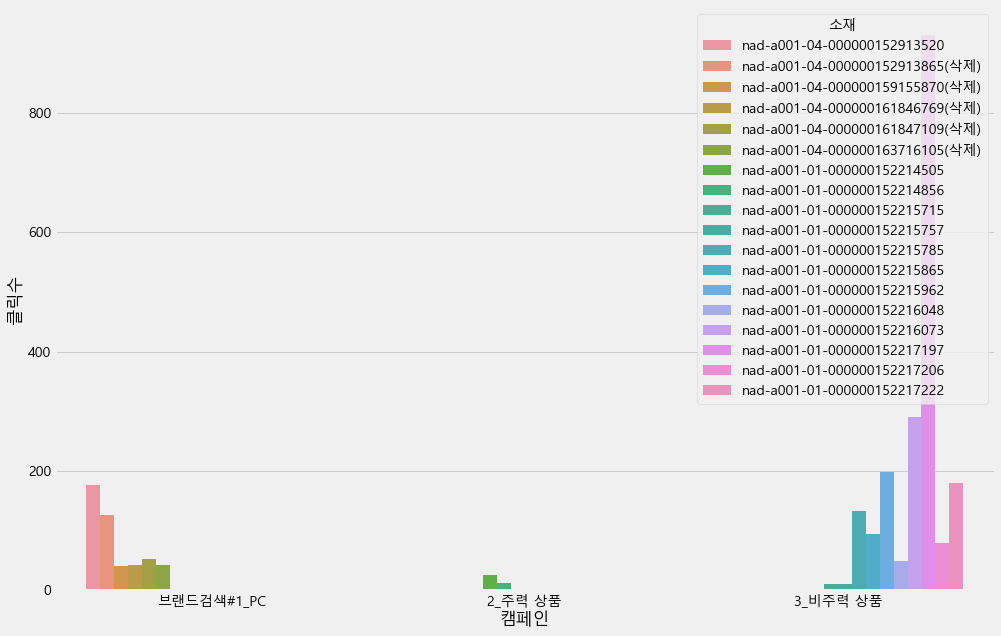

In [148]:
plt.figure(figsize=(15, 10))
df_by_group_label = df_nc10.groupby(['캠페인유형', '캠페인', '광고그룹', '소재']).sum().reset_index()
sns.barplot(x='캠페인', y='클릭수', hue='소재',data=df_by_group_label )
plt.show()

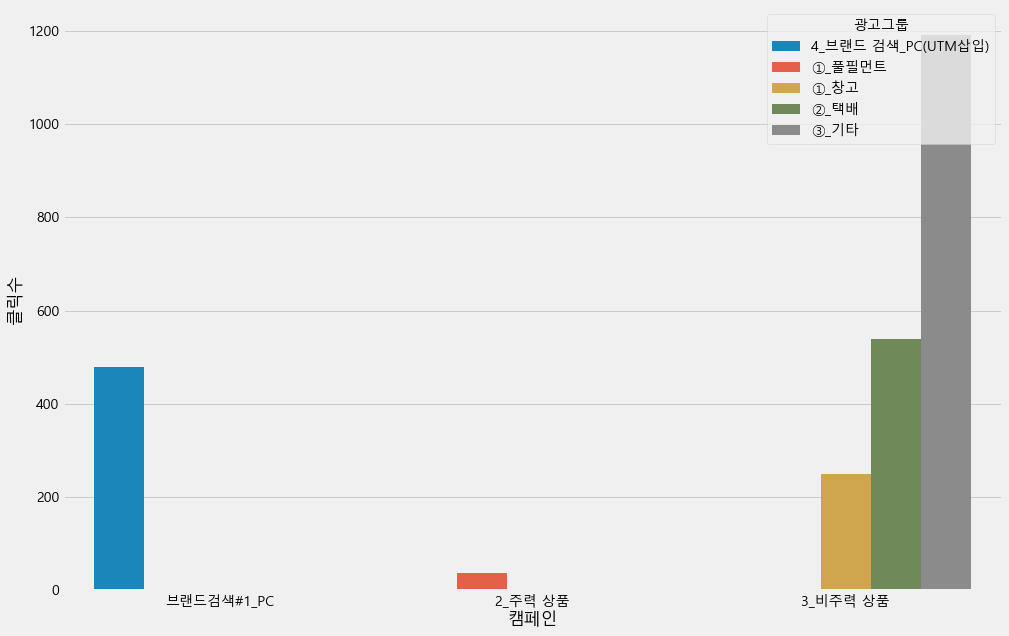

In [179]:
plt.figure(figsize=(15, 10))
df_by_group_label = df_nc10.groupby(['캠페인유형', '캠페인', '광고그룹']).sum().reset_index()
sns.barplot(x='캠페인', y='클릭수', hue='광고그룹',data=df_by_group_label )
plt.show()

In [150]:
df_nc10[df_nc10['소재']=='nad-a001-01-000000152217197']

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
37,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,OMS,8784,13,0.15,656,8525,1.5,0,0.0,0
38,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,맞팔,391594,150,0.04,91,13706,1.2,0,0.0,0
39,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,모두먼트,404,10,2.48,79,792,1.8,0,0.0,0
40,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,상차,46118,17,0.04,97,1650,1.4,0,0.0,0
41,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,서이추,120594,44,0.04,90,3949,2.1,0,0.0,0
42,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,수송,94907,32,0.04,134,4279,1.9,0,0.0,0
43,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,스큐,89403,27,0.04,166,4477,1.1,0,0.0,0
44,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,싸대기,259737,54,0.03,79,4290,1.1,0,0.0,0
45,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,입고,186717,46,0.03,88,4026,1.6,0,0.0,0
46,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,적재,155398,28,0.02,240,6732,1.6,0,0.0,0


In [100]:
df_nc10.groupby(['캠페인유형', '캠페인', '광고그룹', '소재', '키워드']).sum()

노출수  \
캠페인유형 캠페인        광고그룹               소재                              키워드                 
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520     콜로세움3PL        33   
                                                                    콜로세움물류         87   
                                                                    콜로세움코퍼레이션     208   
                                                                    콜로세움풀필먼트      152   
                                    nad-a001-04-000000152913865(삭제) 콜로세움3PL        26   
...                                                                               ...   
파워링크  3_비주력 상품   ③_기타               nad-a001-01-000000152217222     맞팔          34870   
                                                                    싸대기         94246   
                                                                    출고         361709   
                                                                    피킹          25766   
                                                                    하차         121291   

                                                                               클릭수  \
캠페인유형 캠페인        광고그룹               소재                              키워드              
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520     콜로세움3PL     21   
                                                                    콜로세움물류      54   
                                                                    콜로세움코퍼레이션   55   
                                                                    콜로세움풀필먼트    46   
                                    nad-a001-04-000000152913865(삭제) 콜로세움3PL     20   
...                                                                            ...   
파워링크  3_비주력 상품   ③_기타               nad-a001-01-000000152217222     맞팔          16   
                                                                    싸대기         23   
                                                                    출고          98   
                                                                    피킹          16   
                                                                    하차          27   

                                                                               클릭률(%)  \
캠페인유형 캠페인        광고그룹               소재                              키워드                 
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520     콜로세움3PL     63.64   
                                                                    콜로세움물류      62.07   
                                                                    콜로세움코퍼레이션   26.45   
                                                                    콜로세움풀필먼트    30.27   
                                    nad-a001-04-000000152913865(삭제) 콜로세움3PL     76.93   
...                                                                               ...   
파워링크  3_비주력 상품   ③_기타               nad-a001-01-000000152217222     맞팔           0.05   
                                                                    싸대기          0.03   
                                                                    출고           0.03   
                                                                    피킹           0.07   
                                                                    하차           0.03   

                                                                               평균클릭비용(VAT포함,원)  \
캠페인유형 캠페인        광고그룹               소재                              키워드                          
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000152913520     콜로세움3PL                  0   
                                                                    콜로세움물류                   0   
                                                                    콜로세움코퍼레이션                0   
                                                                    콜로세움풀필먼트                 0   
                                    nad-a001-04-00000015291

In [103]:
df_nc10[df_nc10['소재']=='nad-a001-01-000000152217197']

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
37,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,OMS,8784,13,0.15,656,8525,1.5,0,0.0,0
38,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,맞팔,391594,150,0.04,91,13706,1.2,0,0.0,0
39,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,모두먼트,404,10,2.48,79,792,1.8,0,0.0,0
40,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,상차,46118,17,0.04,97,1650,1.4,0,0.0,0
41,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,서이추,120594,44,0.04,90,3949,2.1,0,0.0,0
42,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,수송,94907,32,0.04,134,4279,1.9,0,0.0,0
43,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,스큐,89403,27,0.04,166,4477,1.1,0,0.0,0
44,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,싸대기,259737,54,0.03,79,4290,1.1,0,0.0,0
45,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,입고,186717,46,0.03,88,4026,1.6,0,0.0,0
46,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,적재,155398,28,0.02,240,6732,1.6,0,0.0,0


In [104]:
df_nc10[df_nc10['소재']=='nad-a001-04-000000152913520']

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
60,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000152913520,콜로세움3PL,33,21,63.64,0,0,1.0,1,4.76,0
61,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000152913520,콜로세움물류,87,54,62.07,0,0,1.0,1,1.85,0
62,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000152913520,콜로세움코퍼레이션,208,55,26.45,0,0,1.0,1,1.82,0
63,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000152913520,콜로세움풀필먼트,152,46,30.27,0,0,1.0,2,4.35,0


In [199]:
df_nc10.sort_values('클릭수', ascending=False).head(20)

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
47,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,출고,1487893,353,0.03,100,35222,1.4,0,0.00,0
38,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,맞팔,391594,150,0.04,91,13706,1.2,0,0.00,0
57,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217222,출고,361709,98,0.03,99,9746,1.3,0,0.00,0
50,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217197,하차,400701,83,0.03,107,8855,1.6,0,0.00,0
8,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215785,송파창고,180833,78,0.05,350,27313,1.5,0,0.00,0
28,파워링크,3_비주력 상품,②_택배,nad-a001-01-000000152216073,방문택배,12168,67,0.56,459,30756,5.2,0,0.00,0
13,파워링크,3_비주력 상품,①_창고,nad-a001-01-000000152215865,송파창고,171981,67,0.04,335,22418,1.6,0,0.00,0
53,파워링크,3_비주력 상품,③_기타,nad-a001-01-000000152217206,출고,173266,59,0.04,99,5841,1.3,0,0.00,0
29,파워링크,3_비주력 상품,②_택배,nad-a001-01-000000152216073,택배,254176,58,0.03,455,26411,3.9,0,0.00,0
62,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000152913520,콜로세움코퍼레이션,208,55,26.45,0,0,1.0,1,1.82,0


### 클릭수 9이하

In [109]:
df_nc9 = df_n[df_n['클릭수']<10]
df_nc9

,캠페인유형,캠페인,광고그룹,소재,키워드,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",평균노출순위,전환수,전환율(%),전환당비용(원)
0,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,11번가물류,43,0,0.00,0,0,1.6,0,0.0,0
1,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류,10,0,0.00,0,0,21.4,0,0.0,0
2,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류견적,404,0,0.00,0,0,5.5,0,0.0,0
3,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류대행,708,0,0.00,0,0,11.1,0,0.0,0
4,파워링크,2_주력 상품,①_풀필먼트,nad-a001-01-000000152214505,3자물류비용,657,0,0.00,0,0,9.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5113,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움물류센터,1,1,100.00,0,0,1.0,0,0.0,0
5114,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움이커머스,1,1,100.00,0,0,1.0,0,0.0,0
5115,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움창고,1,1,100.00,0,0,1.0,0,0.0,0
5117,브랜드검색,브랜드검색#1_PC,4_브랜드 검색_PC(UTM삽입),nad-a001-04-000000163716105(삭제),콜로세움풀필먼트,47,9,19.15,0,0,1.0,0,0.0,0


In [111]:
df_nc9.groupby(['캠페인유형', '캠페인', '광고그룹', '소재']).sum()

클릭수  \
캠페인유형 캠페인        광고그룹               소재                                     
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000151618400(삭제)    2   
                                    nad-a001-04-000000151618416(삭제)    2   
                                    nad-a001-04-000000152132567(삭제)    6   
                                    nad-a001-04-000000152132588(삭제)    9   
                                    nad-a001-04-000000152913520        2   
                                    nad-a001-04-000000152913865(삭제)    8   
                                    nad-a001-04-000000159155535(삭제)   27   
                                    nad-a001-04-000000159155870(삭제)    8   
                                    nad-a001-04-000000159515402(삭제)   25   
                                    nad-a001-04-000000161668022(삭제)    4   
                                    nad-a001-04-000000161668219(삭제)    5   
                                    nad-a001-04-000000161846769(삭제)   10   
                                    nad-a001-04-000000161847109(삭제)    9   
                                    nad-a001-04-000000163716105(삭제)   12   
                                    nad-a001-04-000000165240705        1   
파워링크  2_주력 상품    ①_풀필먼트             nad-a001-01-000000152214505      106   
                                    nad-a001-01-000000152214525       36   
                                    nad-a001-01-000000152214552       43   
                                    nad-a001-01-000000152214572       43   
                                    nad-a001-01-000000152214856      126   
                 ②_드랍쉬핑             nad-a001-01-000000152214940       40   
                                    nad-a001-01-000000152214956        6   
                                    nad-a001-01-000000152214983       14   
                                    nad-a001-01-000000152214993       28   
                                    nad-a001-01-000000152215155       14   
                 ③_3PL/4PL          nad-a001-01-000000152215209       65   
                                    nad-a001-01-000000152215271        9   
                                    nad-a001-01-000000152215280       62   
                                    nad-a001-01-000000152215298       11   
                                    nad-a001-01-000000152215320       14   
                 ④_냉장냉동             nad-a001-01-000000152215459(삭제)    8   
                                    nad-a001-01-000000152215474       59   
                                    nad-a001-01-000000152215538       36   
                                    nad-a001-01-000000152215552        6   
                                    nad-a001-01-000000152215616        6   
                                    nad-a001-01-000000159157452        0   
      3_비주력 상품   ①_창고               nad-a001-01-000000152215715       41   
                                    nad-a001-01-000000152215757       18   
                                    nad-a001-01-000000152215785      196   
                                    nad-a001-01-000000152215865      180   
                 ②_택배               nad-a001-01-000000152215916        2   
                                    nad-a001-01-000000152215962       86   
                                    nad-a001-01-000000152216048       47   
                                    nad-a001-01-000000152216073       69   
                 ③_기타               nad-a001-01-000000152217197       97   
                                    nad-a001-01-000000152217206       29   
                                    nad-a001-01-000000152217222       53   

                                                                     클릭률(%)  \
캠페인유형 캠페인        광고그룹               소재                                        
브랜드검색 브랜드검색#1_PC 4_브랜드 검색_PC(UTM삽입) nad-a001-04-000000151618400(삭제)   50.00   
                                    nad-a001-04-000000151618416(삭제)  125.00   
                            

In [112]:
# 5039
df_nc9['클릭수'].sum()

1680

In [113]:
# 80
df_nc10['클릭수'].sum()

2496